In [1]:

# --- Environment setup ---
# If running in a fresh environment, uncomment:
# %pip install datasets torch matplotlib

import re
import io
import json
import math
import random
from collections import Counter, defaultdict, deque
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")

# Flip to False once you have internet access and want the real HF corpora.
OFFLINE_MODE = False

# Requested corpus size per class once running against the real HF datasets (OFFLINE_MODE=False).
# Set above 8,000 to leave headroom: loaders request this many *candidate* rows, but the final
# balanced count per class = min(deduped yield across all 4 sources), so a buffer above your
# actual target absorbs losses from de-duplication and length filtering.
TARGET_SAMPLES_PER_CLASS = 10000

# Binary classifier now -- "personal" and "working" memory were dropped:
# personal-data extraction happens downstream via span/entity extraction over
# arbitrary text, not via a whole-sentence memory-type label.
LABELS = ["semantic", "episodic"]
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
IDX2LABEL = {i: l for l, i in LABEL2IDX.items()}

OUT_DIR = Path("artifacts")
OUT_DIR.mkdir(exist_ok=True)


Using device: mps



## Phase 1 — Data Aggregation

Each loader below pulls from one or more real Hugging Face corpora, extracts the field(s)
that match the target linguistic profile, normalizes it, and returns a deduplicated list of
clean strings. `semantic` and `episodic` each merge **4 sources** (see `_merge_sources`)
instead of a single dataset, so the model sees varied sentence length, topic, and register
within each class rather than memorizing one source's formatting quirks.

**Design choice — stopwords are kept, not stripped.** Pronouns and function words
(`i`, `my`, `you`, `we`) plus tense markers (`yesterday`, `last week`, `remember when`)
are the strongest signals separating `episodic` (first-person, past-tense, situated in
time) from `semantic` (third-person, atemporal, objective). Removing them the way a
generic text-classification pipeline would throws away exactly the signal this
classifier depends on.


In [2]:

# --- Text normalization utilities ---

MIN_CHARS, MAX_CHARS = 8, 300

def clean_text(t: str) -> str:
    if t is None:
        return ""
    t = t.replace("_comma_", ",")          # empathetic_dialogues artifact
    t = re.sub(r"\s+", " ", t).strip()
    return t

def is_valid(t: str) -> bool:
    return bool(t) and MIN_CHARS <= len(t) <= MAX_CHARS


In [3]:
# Make sure to run: pip install datasets
from datasets import DatasetDict, concatenate_datasets, load_dataset


def clean_text(text):
    """Basic helper to ensure string sanitation."""
    if not text:
        return ""
    return str(text).strip().replace("\n", " ")


def is_valid(text):
    """Filters out empty or overly short sentences."""
    return len(text.split()) > 3


def load_all_splits(dataset_name, **kwargs):
    ds = load_dataset(dataset_name, **kwargs)
    if isinstance(ds, DatasetDict):
        splits = list(ds.values())
        if len(splits) == 1:
            return splits[0]
        return concatenate_datasets(splits)
    return ds


def _merge_sources(source_fns, limit, rng_seed=SEED):
    # Round-robins across several (name, fn) loaders, dedupes globally, and
    # shuffles so the final corpus isn't dominated by whichever source is
    # first or biggest. Each source is wrapped so one failing/rate-limited
    # dataset doesn't take the whole class down -- it just contributes less
    # variance instead of crashing the whole aggregation step.
    rng = random.Random(rng_seed)
    per_source_cap = max(200, math.ceil(limit / max(1, len(source_fns))) * 2)
    pooled, seen = [], set()
    for name, fn in source_fns:
        try:
            chunk = fn(limit=per_source_cap)
            added = 0
            for t in chunk:
                if t not in seen:
                    seen.add(t)
                    pooled.append(t)
                    added += 1
            print(f"    + {name:28s}: {added} unique rows")
        except Exception as exc:
            print(f"    ! {name:28s}: skipped ({type(exc).__name__}: {exc})")
    rng.shuffle(pooled)
    return pooled[:limit]


# --- Semantic Memory: multiple sources for register/length/topic variance ---
# Single-source (wiki_qa only) meant the model was learning "Q&A snippet
# formatting" rather than "objective/atemporal fact". Mixing in SQuAD
# (dense encyclopedic paragraphs), SciQ (science explanations) and
# OpenBookQA (terse one-clause facts) spreads out sentence length, domain,
# and phrasing style while keeping the third-person/no-episodic-time signal.

def load_semantic_wikiqa(limit=1000000):
    '''microsoft/wiki_qa -> 'answer' field (Wikipedia QA snippets).'''
    ds = load_all_splits("microsoft/wiki_qa", trust_remote_code=True)
    texts, seen = [], set()
    for row in ds:
        t = clean_text(row["answer"])
        if is_valid(t) and t not in seen:
            seen.add(t)
            texts.append(t)
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_semantic_squad(limit=1000000):
    '''rajpurkar/squad -> 'context' field, split into sentences
    (dense encyclopedic paragraphs -> individual factual sentences).'''
    ds = load_all_splits("rajpurkar/squad")
    texts, seen = [], set()
    seen_context = set()
    for row in ds:
        ctx = row.get("context", "")
        if ctx in seen_context:
            continue
        seen_context.add(ctx)
        for sent in re.split(r"(?<=[.!?])\s+", ctx):
            t = clean_text(sent)
            if is_valid(t) and t not in seen:
                seen.add(t)
                texts.append(t)
            if len(texts) >= limit:
                break
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_semantic_sciq(limit=1000000):
    '''allenai/sciq -> 'support' field (short science-fact explanations).'''
    ds = load_all_splits("allenai/sciq")
    texts, seen = [], set()
    for row in ds:
        t = clean_text(row.get("support", ""))
        if is_valid(t) and t not in seen:
            seen.add(t)
            texts.append(t)
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_semantic_openbookqa(limit=1000000):
    '''allenai/openbookqa (additional config) -> 'fact1' field
    (terse single-clause facts -- adds short-sentence variance).'''
    ds = load_all_splits("allenai/openbookqa", name="additional")
    texts, seen = [], set()
    for row in ds:
        t = clean_text(row.get("fact1", ""))
        if is_valid(t) and t not in seen:
            seen.add(t)
            texts.append(t)
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_semantic_memory(limit=1000000):
    '''Semantic Memory: Objective, atemporal facts & definitions.
    Merged from 4 sources (wiki_qa, squad, sciq, openbookqa) for
    register/length/topic variance -- see _merge_sources.'''
    print("  Aggregating semantic memory from 4 sources...")
    return _merge_sources(
        [
            ("wiki_qa", load_semantic_wikiqa),
            ("squad_context_sentences", load_semantic_squad),
            ("sciq_support", load_semantic_sciq),
            ("openbookqa_fact1", load_semantic_openbookqa),
        ],
        limit=limit,
    )


# --- Episodic Memory: multiple sources for register/length/topic variance ---
# Single-source (empathetic_dialogues only) meant every example was a short,
# emotionally-flavored conversational opener. Adding Reddit TIFU (longer real
# autobiographical anecdotes), ROCStories (short past-tense commonsense
# narratives) and DailyDialog (everyday recount-style utterances) spreads out
# length, formality, and topic while keeping the first-person/past-event signal.

def load_episodic_empathetic(limit=1000000):
    '''facebook/empathetic_dialogues -> 'prompt' field.'''
    try:
        ds = load_all_splits("facebook/empathetic_dialogues", trust_remote_code=True)
        texts, seen = [], set()
        for row in ds:
            t = clean_text(row["prompt"])
            if is_valid(t) and t not in seen:
                seen.add(t)
                texts.append(t)
            if len(texts) >= limit:
                break
        return texts[:limit]
    except Exception as exc:
        print(f"    empathetic_dialogues HF load failed ({type(exc).__name__}): {exc}")
        print("    Falling back to direct empatheticdialogues.tar.gz download...")
        import csv
        import io as _io
        import os
        import ssl
        import tarfile
        import tempfile
        import urllib.request

        archive_path = OUT_DIR / "empatheticdialogues.tar.gz"
        if not archive_path.exists():
            url = "https://dl.fbaipublicfiles.com/parlai/empatheticdialogues/empatheticdialogues.tar.gz"
            ctx = ssl._create_unverified_context()
            fd, tmp_path = tempfile.mkstemp(suffix=".tar.gz")
            os.close(fd)
            try:
                with urllib.request.urlopen(url, context=ctx) as resp, open(tmp_path, "wb") as out:
                    while True:
                        chunk = resp.read(1024 * 1024)
                        if not chunk:
                            break
                        out.write(chunk)
                os.replace(tmp_path, archive_path)
            finally:
                if os.path.exists(tmp_path):
                    os.remove(tmp_path)

        texts, seen = [], set()
        with tarfile.open(archive_path, "r:gz") as tar:
            csv_members = sorted(
                [m for m in tar.getmembers() if m.name.endswith(".csv")],
                key=lambda m: m.name,
            )
            for member_info in csv_members:
                member = tar.extractfile(member_info)
                if member is None:
                    continue
                reader = csv.DictReader(_io.TextIOWrapper(member, encoding="utf-8"))
                for row in reader:
                    t = clean_text(row.get("prompt", ""))
                    if is_valid(t) and t not in seen:
                        seen.add(t)
                        texts.append(t)
                    if len(texts) >= limit:
                        break
                if len(texts) >= limit:
                    break
        return texts[:limit]


def load_episodic_reddit_tifu(limit=1000000):
    '''reddit_tifu (short config) -> 'tldr' field
    (real one/two-sentence autobiographical anecdotes, past tense).'''
    ds = load_all_splits("reddit_tifu", name="short", trust_remote_code=True)
    texts, seen = [], set()
    for row in ds:
        t = clean_text(row.get("tldr", ""))
        if is_valid(t) and t not in seen:
            seen.add(t)
            texts.append(t)
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_episodic_rocstories(limit=1000000):
    '''ROCStories -> concatenated sentence1..sentence5 fields
    (short past-tense commonsense narratives).'''
    ds = load_all_splits("Ximing/ROCStories")
    texts, seen = [], set()
    sent_keys = [f"sentence{i}" for i in range(1, 6)]
    for row in ds:
        parts = [clean_text(row[k]) for k in sent_keys if k in row and row[k]]
        t = clean_text(" ".join(parts))
        if is_valid(t) and t not in seen:
            seen.add(t)
            texts.append(t)
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_episodic_dailydialog(limit=1000000):
    '''li2017dailydialog/daily_dialog -> 'dialog' field, flattened
    (everyday recount-style utterances -- adds conversational-but-mundane variance).'''
    ds = load_all_splits("li2017dailydialog/daily_dialog", trust_remote_code=True)
    texts, seen = [], set()
    for row in ds:
        for utt in row.get("dialog", []):
            t = clean_text(utt)
            if is_valid(t) and t not in seen:
                seen.add(t)
                texts.append(t)
            if len(texts) >= limit:
                break
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_episodic_memory(limit=1000000):
    '''Episodic Memory: Past-tense, situational, first-person events.
    Merged from 4 sources (empathetic_dialogues, reddit_tifu, ROCStories,
    daily_dialog) for register/length/topic variance -- see _merge_sources.'''
    print("  Aggregating episodic memory from 4 sources...")
    return _merge_sources(
        [
            ("empathetic_dialogues", load_episodic_empathetic),
            ("reddit_tifu_tldr", load_episodic_reddit_tifu),
            ("rocstories", load_episodic_rocstories),
            ("daily_dialog_utterances", load_episodic_dailydialog),
        ],
        limit=limit,
    )


HF_LOADERS = {
    "semantic": load_semantic_memory,
    "episodic": load_episodic_memory,
}


/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

# --- Offline synthetic fallback (only used when OFFLINE_MODE = True) ---
# Templated generators that mimic each source's linguistic profile, so the rest of the
# notebook (vectorizer, MLP, training, evaluation) can be exercised without internet access.

def _build_synthetic_corpus(seed=SEED, n_per_class=500):
    rng = random.Random(seed)

    semantic_templates = [
        "The {concept} is defined as the {def_}.",
        "{Concept} refers to a process by which {process}.",
        "In physics, {concept} describes the relationship between {a} and {b}.",
        "The capital of {country} is {city}.",
        "{Concept} was first described in {year} by researchers studying {field}.",
        "A {concept} is a type of {category} found in {field}.",
    ]
    episodic_templates = [
        "Yesterday I went to the {place} and met {person}.",
        "Last week I was feeling {adj} after the {event}.",
        "We celebrated my {relation}'s birthday at {place} last month.",
        "I remember when I first {action} back in {year}.",
        "During the trip, I visited {place} and it was {adj}.",
        "This morning I {action} before heading to work.",
        "Last summer I {action} with {person} in {place}.",
        "A few months ago I {action} and it felt {adj}.",
        "Back in {year} I {action} while visiting {place}.",
        "Earlier this year I {action} with my {relation}.",
    ]
    fillers = {
        "adj": ["curious","happy","nervous","excited","calm","tired","anxious","confident"],
        "place": ["Paris","the mountains","a small town","New York","the beach","the library","a cafe"],
        "concept": ["photosynthesis","gravity","inflation","democracy","osmosis","entropy"],
        "Concept": ["Photosynthesis","Gravity","Inflation","Democracy","Osmosis","Entropy"],
        "def_": ["conversion of light into chemical energy","force attracting masses",
                 "rise in prices over time","measure of disorder in a system"],
        "process": ["plants convert sunlight into energy","cells divide",
                    "water moves across a membrane","heat flows between two bodies"],
        "a": ["mass","voltage","supply","pressure"],
        "b": ["acceleration","current","demand","volume"],
        "category": ["organelle","economic indicator","political system","physical law"],
        "country": ["France","Japan","Germany","Brazil","Canada"],
        "city": ["Paris","Tokyo","Berlin","Brasilia","Ottawa"],
        "year": ["1928","1953","1687","2001","1867"],
        "field": ["genetics","chemistry","astronomy","economics"],
        "person": ["Sarah","the client","Dr. Lee","my manager","the team"],
        "event": ["exam","interview","storm","deadline"],
        "relation": ["sister","brother","mom","friend","cousin"],
        "action": ["rode a bike","cooked dinner","flew on a plane","went for a run","read a book"],
    }

    def fill(t):
        out = t
        for k, vals in fillers.items():
            if "{" + k + "}" in out:
                out = out.replace("{" + k + "}", rng.choice(vals))
        return out

    def gen(templates, n):
        return [fill(rng.choice(templates)) for _ in range(n)]

    return {
        "semantic": gen(semantic_templates, n_per_class),
        "episodic": gen(episodic_templates, n_per_class),
    }



In [5]:

# --- Build the unified corpus ---

def build_balanced_records(raw_data, seed=SEED, sample_frac=1.0):
    """Shuffle each class independently, then cut a balanced slice.

    sample_frac < 1.0 lets the training loop draw a different subset each epoch
    instead of reusing the exact same rows every time.
    """
    rng = random.Random(seed)
    by_label = {}
    for label, texts in raw_data.items():
        shuffled = list(texts)
        rng.shuffle(shuffled)
        take = max(1, int(len(shuffled) * sample_frac))
        by_label[label] = shuffled[:take]

    min_count = min(len(v) for v in by_label.values())
    records = []
    for label, texts in by_label.items():
        records.extend({"text": t, "label": label} for t in texts[:min_count])

    rng.shuffle(records)
    return records, min_count


def merge_novel_dataset(raw_data, novel_path=Path("data/novel_classifier_dataset.json")):
    """Add the labeled novel dataset into the already-loaded class buckets."""
    if not novel_path.exists():
        print(f"Novel dataset not found at {novel_path}; skipping merge.")
        return raw_data

    with open(novel_path) as f:
        novel_rows = json.load(f)

    added = defaultdict(int)
    for row in novel_rows:
        label = row.get("label")
        text = clean_text(row.get("text", ""))
        if label not in raw_data or not is_valid(text):
            continue
        raw_data[label].append(text)
        added[label] += 1

    for label, count in added.items():
        print(f"Added {count} novel {label} rows from {novel_path.name}")
    return raw_data


if OFFLINE_MODE:
    print("OFFLINE_MODE=True -> using synthetic stand-in corpus (no internet required).")
    raw_data = _build_synthetic_corpus(n_per_class=600)
else:
    print("OFFLINE_MODE=False -> pulling real corpora from the Hugging Face Hub...")
    try:
        raw_data = {label: fn(limit=TARGET_SAMPLES_PER_CLASS) for label, fn in HF_LOADERS.items()}
    except Exception as exc:
        print(f"HF download failed ({type(exc).__name__}): {exc}")
        print("Falling back to synthetic stand-in corpus so the notebook can continue.")
        raw_data = _build_synthetic_corpus(n_per_class=600)

raw_data = merge_novel_dataset(raw_data)

for label, texts in raw_data.items():
    print(f"{label:10s}: {len(texts)} raw samples")

# Build one balanced corpus for the initial split, but shuffle before cutting so
# the selected rows are not always the same prefix of each source.
records, min_count = build_balanced_records(raw_data, seed=SEED, sample_frac=1.0)
print(f"\nBalancing both classes to {min_count} samples each")
print(f"Total unified corpus: {len(records)} records")

with open(OUT_DIR / "corpus.json", "w") as f:
    json.dump(records, f, indent=2)



`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'microsoft/wiki_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


OFFLINE_MODE=False -> pulling real corpora from the Hugging Face Hub...
  Aggregating semantic memory from 4 sources...


    + wiki_qa                     : 5000 unique rows
    + squad_context_sentences     : 5000 unique rows
    + sciq_support                : 5000 unique rows


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/empathetic_dialogues' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


    + openbookqa_fact1            : 1282 unique rows
  Aggregating episodic memory from 4 sources...
    empathetic_dialogues HF load failed (RuntimeError): Dataset scripts are no longer supported, but found empathetic_dialogues.py
    Falling back to direct empatheticdialogues.tar.gz download...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'reddit_tifu' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


    + empathetic_dialogues        : 5000 unique rows


Using the latest cached version of the dataset since reddit_tifu couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'short' at /Users/sasidharjasty/.cache/huggingface/datasets/reddit_tifu/short/1.1.0/3136b11fbef3f2517de1d720621af110bd29e6083aebeab0d8ec198c9f95dc95 (last modified on Mon Jul 20 19:46:20 2026).
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'li2017dailydialog/daily_dialog' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


    + reddit_tifu_tldr            : 5000 unique rows
    ! rocstories                  : skipped (DatasetNotFoundError: Dataset 'Ximing/ROCStories' doesn't exist on the Hub or cannot be accessed.)
    ! daily_dialog_utterances     : skipped (RuntimeError: Dataset scripts are no longer supported, but found daily_dialog.py)
Novel dataset not found at data/novel_classifier_dataset.json; skipping merge.
semantic  : 10000 raw samples
episodic  : 10000 raw samples

Balancing both classes to 10000 samples each
Total unified corpus: 20000 records


In [6]:

# --- Stratified train / val / test split (pure Python, no sklearn) ---

def stratified_split(records, val_frac=0.15, test_frac=0.15, seed=SEED):
    by_label = defaultdict(list)
    for r in records:
        by_label[r["label"]].append(r)

    train, val, test = [], [], []
    split_rng = random.Random(seed)
    for label, items in by_label.items():
        split_rng.shuffle(items)
        n = len(items)
        n_val = int(n * val_frac)
        n_test = int(n * test_frac)
        val.extend(items[:n_val])
        test.extend(items[n_val:n_val + n_test])
        train.extend(items[n_val + n_test:])

    split_rng.shuffle(train); split_rng.shuffle(val); split_rng.shuffle(test)
    return train, val, test

train_records, val_records, test_records = stratified_split(records)
print(f"train={len(train_records)}  val={len(val_records)}  test={len(test_records)}")


train=14000  val=3000  test=3000


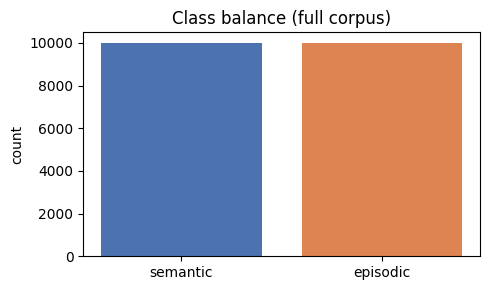


Sample records:
  [semantic  ] Set between 1839 and 1889, it follows four generations of a family (starting as the Prescotts) as they move ever westward, from western New York state to the Pacific Ocean .
  [episodic  ] I beat level 150 on my favorite game Grim Dawn this morning. I've been grinding levels all week!


In [7]:

# --- Sanity check: class balance + example rows ---

fig, ax = plt.subplots(figsize=(5, 3))
counts = [sum(1 for r in records if r["label"] == l) for l in LABELS]
ax.bar(LABELS, counts, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax.set_title("Class balance (full corpus)")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

print("\nSample records:")
for label in LABELS:
    example = next(r["text"] for r in records if r["label"] == label)
    print(f"  [{label:10s}] {example}")



## Phase 2 — Custom TF-IDF Vectorizer (pure Python, no sklearn)

Standard TF-IDF, built from scratch with `re` + `collections.Counter` + `math.log`:

- **Tokenizer**: lowercase word tokens + bigrams (`use_bigrams=True`) — bigrams capture
  short imperative phrases like `"turn_off"` or `"schedule_a"` that unigrams alone miss.
- **Vocabulary pruning**: `min_df` / `max_df_ratio` drop terms that are too rare (noise) or
  too common (uninformative across all four classes), then keep the top `max_features` by
  document frequency.
- **Weighting**: sublinear TF (`1 + log(tf)`) dampens the effect of a term repeated many
  times in one document, combined with smoothed IDF (`ln((1+N)/(1+df)) + 1`).
- **Normalization**: each vector is L2-normalized, which is what lets a plain dot product
  behave like cosine similarity and keeps the MLP's input scale stable across documents of
  very different lengths.


In [8]:

TOKEN_RE = re.compile(r"[a-zA-Z0-9:_/-]+")

def tokenize(text: str, use_bigrams: bool = True):
    tokens = [t.lower() for t in TOKEN_RE.findall(text)]
    if use_bigrams:
        bigrams = [f"{a}_{b}" for a, b in zip(tokens, tokens[1:])]
        return tokens + bigrams
    return tokens


class TFIDFVectorizer:
    '''Deterministic TF-IDF vectorizer implemented with base Python only
    (re, collections.Counter, math) — no scikit-learn.'''

    def __init__(self, max_features=10000, min_df=2, max_df_ratio=0.9,
                 use_bigrams=True, sublinear_tf=True):
        self.max_features = max_features
        self.min_df = min_df
        self.max_df_ratio = max_df_ratio
        self.use_bigrams = use_bigrams
        self.sublinear_tf = sublinear_tf
        self.vocab_ = {}   # token -> column index
        self.idf_ = {}     # token -> idf weight

    def fit(self, texts):
        n_docs = len(texts)
        df = Counter()
        for text in texts:
            df.update(set(tokenize(text, self.use_bigrams)))

        max_df_count = self.max_df_ratio * n_docs
        candidates = [
            (tok, c) for tok, c in df.items()
            if self.min_df <= c <= max_df_count
        ]
        # Keep the most broadly-attested terms up to the feature cap.
        candidates.sort(key=lambda x: -x[1])
        candidates = candidates[: self.max_features]

        self.vocab_ = {tok: i for i, (tok, _) in enumerate(candidates)}
        self.idf_ = {
            tok: math.log((1 + n_docs) / (1 + c)) + 1.0
            for tok, c in candidates
        }
        return self

    def _vectorize_one(self, text):
        tokens = tokenize(text, self.use_bigrams)
        counts = Counter(t for t in tokens if t in self.vocab_)
        vec = torch.zeros(len(self.vocab_))
        for tok, c in counts.items():
            tf = 1 + math.log(c) if self.sublinear_tf else float(c)
            vec[self.vocab_[tok]] = tf * self.idf_[tok]
        norm = torch.norm(vec, p=2)
        if norm > 0:
            vec = vec / norm
        return vec

    def transform(self, texts):
        return torch.stack([self._vectorize_one(t) for t in texts])

    def fit_transform(self, texts):
        self.fit(texts)
        return self.transform(texts)

    def save(self, path):
        with open(path, "w") as f:
            json.dump({
                "vocab": self.vocab_,
                "idf": self.idf_,
                "max_features": self.max_features,
                "use_bigrams": self.use_bigrams,
                "sublinear_tf": self.sublinear_tf,
            }, f)

    @classmethod
    def load(cls, path):
        with open(path) as f:
            data = json.load(f)
        vec = cls(max_features=data["max_features"],
                   use_bigrams=data["use_bigrams"],
                   sublinear_tf=data["sublinear_tf"])
        vec.vocab_ = data["vocab"]
        vec.idf_ = data["idf"]
        return vec


In [9]:

vectorizer = TFIDFVectorizer(max_features=10000, min_df=2, max_df_ratio=0.9,
                              use_bigrams=True, sublinear_tf=True)

X_train = vectorizer.fit_transform([r["text"] for r in train_records])
y_train = torch.tensor([LABEL2IDX[r["label"]] for r in train_records], dtype=torch.long)

X_val = vectorizer.transform([r["text"] for r in val_records])
y_val = torch.tensor([LABEL2IDX[r["label"]] for r in val_records], dtype=torch.long)

X_test = vectorizer.transform([r["text"] for r in test_records])
y_test = torch.tensor([LABEL2IDX[r["label"]] for r in test_records], dtype=torch.long)

vocab_size = len(vectorizer.vocab_)
sparsity = (X_train == 0).float().mean().item()
print(f"Vocabulary size: {vocab_size}")
print(f"X_train shape:   {tuple(X_train.shape)}")
print(f"Sparsity:        {sparsity:.2%} of entries are zero")

vectorizer.save(OUT_DIR / "tfidf_vectorizer.json")


Vocabulary size: 10000
X_train shape:   (14000, 10000)
Sparsity:        99.72% of entries are zero



## PyTorch `Dataset` / `DataLoader`


In [10]:

class MemoryTextDataset(Dataset):
    def __init__(self, X: torch.Tensor, y: torch.Tensor):
        self.X, self.y = X, y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 128

train_loader = DataLoader(MemoryTextDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(MemoryTextDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(MemoryTextDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)



## Phase 2 — The MLP Classifier (pure PyTorch)

A small feed-forward network: `Linear -> BatchNorm -> ReLU -> Dropout`, stacked twice,
then a final `Linear` to 4 logits. `BatchNorm1d` speeds up convergence on TF-IDF's
high-dimensional, sparsity-heavy input; `Dropout` plus `weight_decay` in the optimizer
keep it from memorizing lexical quirks of any one HF source.


In [11]:

class MemoryClassifierMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(1024, 512,256), num_classes=2, dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = MemoryClassifierMLP(input_dim=vocab_size, hidden_dims=(512, 128),
                             num_classes=len(LABELS), dropout=0.3).to(DEVICE)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")


MemoryClassifierMLP(
  (net): Sequential(
    (0): Linear(in_features=10000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=2, bias=True)
  )
)

Total trainable parameters: 5,187,714



## Training loop — early stopping + LR scheduling

Standard supervised training: `CrossEntropyLoss` + `AdamW`, with `ReduceLROnPlateau`
halving the learning rate when validation loss stalls, and early stopping that restores
the best-validation-loss weights once patience is exhausted.


In [12]:

def evaluate_loss_acc(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


def sample_epoch_records(records, seed, sample_frac=0.85):
    """Shuffle the training split and cut a fresh balanced subset each epoch."""
    by_label = defaultdict(list)
    for record in records:
        by_label[record["label"]].append(record)

    rng = random.Random(seed)
    sampled = []
    for label, items in by_label.items():
        shuffled = list(items)
        rng.shuffle(shuffled)
        take = max(1, int(len(shuffled) * sample_frac))
        sampled.extend(shuffled[:take])

    rng.shuffle(sampled)
    return sampled


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

EPOCHS = 40
PATIENCE = 7
EPOCH_SAMPLE_FRAC = 0.85

best_val_loss = float("inf")
best_state = None
patience_ctr = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    epoch_records = sample_epoch_records(train_records, seed=SEED + epoch, sample_frac=EPOCH_SAMPLE_FRAC)
    X_train_epoch = vectorizer.transform([r["text"] for r in epoch_records])
    y_train_epoch = torch.tensor([LABEL2IDX[r["label"]] for r in epoch_records], dtype=torch.long)
    train_loader = DataLoader(MemoryTextDataset(X_train_epoch, y_train_epoch), batch_size=BATCH_SIZE, shuffle=True)

    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_loss, train_acc = running_loss / total, correct / total
    val_loss, val_acc = evaluate_loss_acc(model, val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d} | train_rows {len(epoch_records):5d} | train_loss {train_loss:.4f} acc {train_acc:.4f} "
          f"| val_loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

model.load_state_dict(best_state)


Epoch 01 | train_rows 11900 | train_loss 0.0935 acc 0.9672 | val_loss 0.0537 acc 0.9820
Epoch 02 | train_rows 11900 | train_loss 0.0188 acc 0.9948 | val_loss 0.0559 acc 0.9807
Epoch 03 | train_rows 11900 | train_loss 0.0061 acc 0.9982 | val_loss 0.0600 acc 0.9827
Epoch 04 | train_rows 11900 | train_loss 0.0028 acc 0.9995 | val_loss 0.0689 acc 0.9777
Epoch 05 | train_rows 11900 | train_loss 0.0018 acc 0.9997 | val_loss 0.0666 acc 0.9797
Epoch 06 | train_rows 11900 | train_loss 0.0008 acc 0.9999 | val_loss 0.0637 acc 0.9800
Epoch 07 | train_rows 11900 | train_loss 0.0010 acc 0.9997 | val_loss 0.0747 acc 0.9767
Epoch 08 | train_rows 11900 | train_loss 0.0006 acc 0.9998 | val_loss 0.0645 acc 0.9793

Early stopping at epoch 8 (best val_loss=0.0537)


<All keys matched successfully>

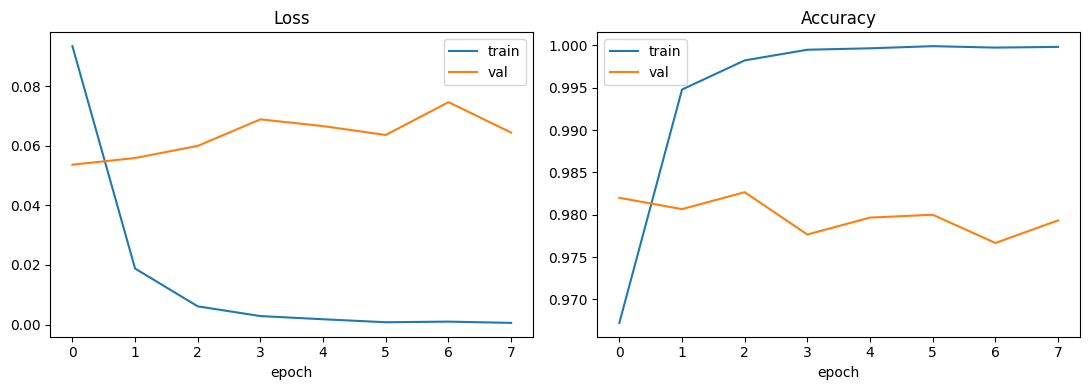

In [13]:

# --- Training curves ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()

plt.tight_layout()
plt.show()



## Evaluation — manual metrics (no sklearn)

Confusion matrix, per-class precision/recall/F1, and overall accuracy, all computed with
plain `torch` tensor operations.


In [14]:

def confusion_matrix(y_true, y_pred, num_classes):
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def classification_report(y_true, y_pred, labels):
    num_classes = len(labels)
    cm = confusion_matrix(y_true, y_pred, num_classes)
    report = {}
    for i, label in enumerate(labels):
        tp = cm[i, i].item()
        fp = cm[:, i].sum().item() - tp
        fn = cm[i, :].sum().item() - tp
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support = cm[i, :].sum().item()
        report[label] = {"precision": precision, "recall": recall, "f1": f1, "support": support}
    accuracy = torch.diag(cm).sum().item() / cm.sum().item()
    return report, accuracy, cm


model.eval()
with torch.no_grad():
    test_logits = model(X_test.to(DEVICE))
    test_preds = test_logits.argmax(1).cpu()

report, accuracy, cm = classification_report(y_test.tolist(), test_preds.tolist(), LABELS)

print(f"Test accuracy: {accuracy:.4f}\n")
print(f"{'class':10s} {'precision':>10s} {'recall':>10s} {'f1':>10s} {'support':>10s}")
for label, m in report.items():
    print(f"{label:10s} {m['precision']:10.3f} {m['recall']:10.3f} {m['f1']:10.3f} {m['support']:10d}")


Test accuracy: 0.9797

class       precision     recall         f1    support
semantic        0.985      0.974      0.980       1500
episodic        0.974      0.985      0.980       1500


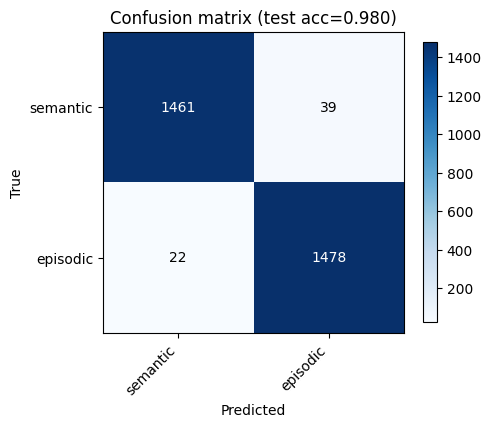

In [15]:

# --- Confusion matrix heatmap ---
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm.numpy(), cmap="Blues")
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (test acc={accuracy:.3f})")

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        val = cm[i, j].item()
        color = "white" if val > cm.max().item() / 2 else "black"
        ax.text(j, i, str(val), ha="center", va="center", color=color)

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()



## Save artifacts

The trained model weights, the TF-IDF vocabulary/IDF table, and the label map are saved
so the classifier can be loaded standalone by the downstream Phase 3 (SPO extraction /
storage routing) and Phase 4 (conflict resolution) components without retraining.


In [16]:

torch.save(model.state_dict(), OUT_DIR / "memory_classifier_mlp.pt")
vectorizer.save(OUT_DIR / "tfidf_vectorizer.json")
with open(OUT_DIR / "label_map.json", "w") as f:
    json.dump({"labels": LABELS, "label2idx": LABEL2IDX}, f, indent=2)

# Also persist the architecture hyperparams needed to reconstruct the model at load time.
with open(OUT_DIR / "model_config.json", "w") as f:
    json.dump({
        "input_dim": vocab_size,
        "hidden_dims": [512, 128],
        "num_classes": len(LABELS),
        "dropout": 0.3,
    }, f, indent=2)

print("Saved to:", [p.name for p in OUT_DIR.iterdir()])


Saved to: ['corpus.json', 'memory_classifier_mlp.pt', 'empatheticdialogues.tar.gz', 'label_map.json', 'tfidf_vectorizer.json', 'model_config.json']



## Inference demo — classify & route

A single deterministic function that takes raw text, vectorizes it with the fitted
TF-IDF vectorizer, runs it through the trained MLP, and returns the predicted memory
type plus a softmax confidence score. This confidence score is exactly the signal Phase 4
(adversarial conflict resolution) will use downstream to decide whether a new fact should
overwrite, supersede, or be rejected against an existing memory entry.


In [17]:

@torch.no_grad()
def classify_and_route(text: str, model=model, vectorizer=vectorizer):
    model.eval()
    vec = vectorizer.transform([text]).to(DEVICE)
    logits = model(vec)
    probs = torch.softmax(logits, dim=1).squeeze(0)
    pred_idx = int(probs.argmax())
    return {
        "text": text,
        "predicted_memory": IDX2LABEL[pred_idx],
        "confidence": round(probs[pred_idx].item(), 4),
        "distribution": {IDX2LABEL[i]: round(p.item(), 4) for i, p in enumerate(probs)},
    }


demo_examples = [
    "Water freezes at 0 degrees Celsius.",
    "Last weekend I visited my grandparents and helped them plant flowers.",

    "The Pacific Ocean is the largest ocean on Earth.",
    "I celebrated my birthday with a small group of close friends last year.",

    "The capital of Australia is Canberra.",
    "During winter break I learned how to ski for the first time.",

    "Photosynthesis converts sunlight into chemical energy.",
    "Last month I attended a live jazz concert downtown.",

    "The Great Wall of China was built over many centuries.",
    "I met my childhood best friend at a reunion last summer.",

    "Venus is the hottest planet in the solar system.",
    "Yesterday I accidentally left my backpack on the bus but got it back.",

    "The human body has 206 bones.",
    "Last fall I volunteered at a local food bank.",

    "Mount Everest is the tallest mountain above sea level.",
    "I watched the northern lights during a trip to Iceland.",

    "The speed of light is approximately 299,792 kilometers per second.",
    "When I was ten years old I broke my arm riding a bicycle.",

    "The Amazon rainforest produces a significant amount of Earth's oxygen.",
    "I once got caught in a thunderstorm while hiking.",

    "An octagon has eight sides.",
    "Last Christmas my family baked cookies together.",

    "Sharks are fish, not mammals.",
    "I visited the Grand Canyon during a family road trip.",

    "The chemical symbol for sodium is Na.",
    "Last year I completed my first half marathon.",

    "Honey never truly spoils if stored properly.",
    "I accidentally spilled coffee on my laptop during finals week.",

    "Earth revolves around the Sun once every year.",
    "Last spring I planted tomatoes in my backyard.",

    "A triangle's interior angles sum to 180 degrees.",
    "I won first place in a local chess tournament when I was younger.",

    "Python is an interpreted programming language.",
    "Last semester I presented my research at a student conference.",

    "The Moon orbits the Earth.",
    "I went camping beside a lake with my cousins last summer.",

    "Electricity flows through conductive materials.",
    "I learned to swim at a community pool when I was seven.",

    "Saturn is known for its prominent ring system.",
    "I watched a solar eclipse from a nearby park.",

    "Bats are the only mammals capable of sustained flight.",
    "I got lost while exploring an old city during vacation.",

    "The boiling point of water is 100 degrees Celsius at sea level.",
    "I found an old photo album while cleaning the attic.",

    "The Eiffel Tower is located in Paris.",
    "Last weekend I taught my younger cousin how to ride a bike.",

    "Penguins cannot fly.",
    "I spent an afternoon exploring a science museum with friends.",

    "Gold has the chemical symbol Au.",
    "I attended my first orchestra performance last month.",

    "A leap year has 366 days.",
    "I learned how to bake bread during the pandemic.",

    "The Sahara is the world's largest hot desert.",
    "I watched sea turtles hatch during a beach vacation."
]


for ex in demo_examples:
    result = classify_and_route(ex)
    print(f"[{result['predicted_memory']:10s} | conf={result['confidence']:.3f}] {ex}")


#while True:
#    user_input = input("\nEnter a text snippet (or 'exit' to quit): ")
#    if user_input.lower() in {"exit", "quit"}:
#        break
#    result = classify_and_route(user_input)
#    print(f"[{result['predicted_memory']:10s} | conf={result['confidence']:.3f}] {user_input}")
#    print("Distribution:", result["distribution"])



[semantic   | conf=0.966] Water freezes at 0 degrees Celsius.
[episodic   | conf=0.942] Last weekend I visited my grandparents and helped them plant flowers.
[semantic   | conf=1.000] The Pacific Ocean is the largest ocean on Earth.
[episodic   | conf=0.986] I celebrated my birthday with a small group of close friends last year.
[semantic   | conf=0.997] The capital of Australia is Canberra.
[episodic   | conf=0.927] During winter break I learned how to ski for the first time.
[semantic   | conf=0.996] Photosynthesis converts sunlight into chemical energy.
[episodic   | conf=0.997] Last month I attended a live jazz concert downtown.
[semantic   | conf=0.999] The Great Wall of China was built over many centuries.
[episodic   | conf=0.998] I met my childhood best friend at a reunion last summer.
[semantic   | conf=0.998] Venus is the hottest planet in the solar system.
[episodic   | conf=0.999] Yesterday I accidentally left my backpack on the bus but got it back.
[semantic   | conf=0.978


## Phase 3 (partial) — Personal Information Extraction (self vs. other)

The binary `semantic`/`episodic` classifier above tells you *what kind of memory* a
sentence is. It doesn't tell you *who the sentence is about*. A sentence can be
personal-flavored (preferences, traits, biographical facts, contact info, routines) while
still being about someone else entirely -- and that distinction matters a lot if these
extracted spans are going to be stored as facts about *this* user.

`extract_personal_info` below is a rule-based, dependency-free clause scanner (pure Python,
same "no external deps" philosophy as the TF-IDF vectorizer above) that:

1. Splits text into clauses (naive split on sentence-ending `.`/`!`/`?`/`;`, so
   compound subjects like "my friend and I" stay in one clause).
2. For each clause, decides who the **grammatical subject** is:
   - `"self"` — clause is led by `I`/`I'm`/`me`/`myself`, or by `my <attribute>` where
     `<attribute>` is something only the speaker themself can have (name, age, favorite,
     birthday, allergy, phone number, ...).
   - `"other"` — clause is led by a third-person pronoun (`he`/`she`/`they`/...), or by
     `my <relation>` where `<relation>` is another *person* (sister, friend, boss, coworker,
     ...) -- i.e. "my sister's favorite color" is information *about the sister*, not about
     the speaker, even though "my" appears.
   - `None` — no clear subject marker either way.
3. Only `"self"` clauses get scanned for personal-info categories (preference,
   identity/trait, biographical, routine/habit, contact/allergy, possession).

**Known limitation:** this is a lexical heuristic, not a real dependency parse. Multi-clause
sentences joined by "and"/"but" (e.g. "I love pizza and my sister hates it") are scored as
one unit, so a same-clause mention of another person can slip through as self. The
"Next steps" section below still calls out a proper spaCy dependency parse as the
production-grade version of this same idea.


In [18]:

# --- Personal Information Extraction: self vs. other ---
# Pure-Python / regex heuristic (no spaCy dependency) that finds personal-info
# clauses (preferences, traits, biography, routines, contact info) but only
# keeps the ones whose grammatical subject is the speaker themself.

# Nouns that denote *another* person -- if "my {noun}" leads a clause, the
# clause is about that person, not about the speaker, even though "my" appears.
OTHER_PERSON_NOUNS = {
    "sister", "brother", "mom", "mother", "dad", "father", "parent", "parents",
    "friend", "bestfriend", "cousin", "wife", "husband", "boyfriend", "girlfriend",
    "partner", "fiance", "fiancee", "boss", "coworker", "colleague", "manager",
    "teacher", "professor", "roommate", "neighbor", "neighbour", "grandma",
    "grandmother", "grandpa", "grandfather", "aunt", "uncle", "son", "daughter",
    "kid", "kids", "child", "children", "teammate", "client", "doctor", "dentist",
    "nephew", "niece", "classmate", "team", "coach", "landlord", "tenant",
}

# Attributes that only make sense as belonging to the speaker when phrased as
# "my {attribute}" at the head of a clause (name, age, favorite thing, ...).
SELF_ATTRIBUTE_NOUNS = {
    "name", "nickname", "age", "favorite", "favourite", "hobby", "hobbies",
    "job", "occupation", "birthday", "email", "phone", "number", "address",
    "allergy", "allergies", "blood", "zodiac", "personality", "height",
    "weight", "goal", "goals", "routine", "schedule",
}

_SELF_LEAD_RE = re.compile(r"^(i|i'm|i've|i'd|i'll|me|myself)\b")
_OTHER_PRONOUN_LEAD_RE = re.compile(r"^(he|she|they|him|her|them|his|hers|their|theirs)\b")
_COMPOUND_SELF_RE = re.compile(r"\b(and i|i and)\b")
_MY_LEAD_RE = re.compile(r"^my\b")

_SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?;])\s+")

# Verb-hint lexicon used to decide whether "and"/"but" inside a sentence is
# joining two independent CLAUSES ("I love pizza and my sister hates it" ->
# split) or just joining two nouns inside one subject ("my friend and I went
# hiking" -> do NOT split). If a verb-hint has already been seen since the
# last split point, the next "and"/"but" is treated as a clause boundary.
_AUX_VERBS = {
    "am", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "having", "do", "does", "did",
    "will", "would", "can", "could", "shall", "should", "may", "might", "must",
}
_CONTENT_VERB_STEMS = {
    "love", "like", "enjoy", "prefer", "hate", "dislike", "adore",
    "go", "goes", "went", "gone", "going",
    "work", "works", "worked", "working",
    "live", "lives", "lived", "living",
    "visit", "visits", "visited", "visiting",
    "meet", "meets", "met", "meeting",
    "eat", "eats", "ate", "eating",
    "drink", "drinks", "drank", "drinking",
    "play", "plays", "played", "playing",
    "watch", "watches", "watched", "watching",
    "feel", "feels", "felt", "feeling",
    "think", "thinks", "thought", "thinking",
    "want", "wants", "wanted", "wanting",
    "need", "needs", "needed", "needing",
    "get", "gets", "got", "getting",
    "make", "makes", "made", "making",
    "take", "takes", "took", "taking",
    "say", "says", "said", "saying",
    "tell", "tells", "told", "telling",
    "call", "calls", "called", "calling",
    "celebrate", "celebrates", "celebrated",
    "attend", "attends", "attended",
    "learn", "learns", "learned",
    "grew", "born", "found", "finds",
}
_VERB_HINTS = _AUX_VERBS | _CONTENT_VERB_STEMS
# Common -ed nouns short enough to collide with the crude suffix heuristic below.
_SUFFIX_FALSE_POSITIVES = {"bed", "red", "fed", "led", "wed", "shed", "sled"}


def _has_verb_hint(word: str) -> bool:
    bare = re.sub(r"[^\w']", "", word.lower())
    if bare in _VERB_HINTS:
        return True
    if len(bare) >= 4 and bare.endswith("ed") and bare not in _SUFFIX_FALSE_POSITIVES:
        return True
    return False


def _split_conjoined_clauses(sentence: str):
    """Splits a single sentence on 'and'/'but' ONLY at a point where a verb
    has already appeared since the start of the current piece -- i.e. only
    when what precedes is already a complete clause, not just a noun phrase."""
    tokens = sentence.split(" ")
    pieces, current = [], []
    seen_verb = False
    for tok in tokens:
        bare = re.sub(r"[^\w']", "", tok.lower())
        if bare in ("and", "but") and seen_verb and current:
            pieces.append(" ".join(current).strip())
            current = []
            seen_verb = False
            continue
        current.append(tok)
        if _has_verb_hint(tok):
            seen_verb = True
    if current:
        pieces.append(" ".join(current).strip())
    return [p for p in pieces if p]


def _split_clauses(text: str):
    sentences = [s.strip() for s in _SENTENCE_SPLIT_RE.split(text.strip()) if s.strip()]
    clauses = []
    for sent in sentences:
        clauses.extend(_split_conjoined_clauses(sent))
    return clauses


# Capitalized sentence-openers that are NOT personal names, so the
# proper-noun-subject check below doesn't misfire on them.
_NON_NAME_SENTENCE_STARTERS = {
    "my", "the", "a", "an", "this", "that", "these", "those", "yesterday",
    "today", "tomorrow", "last", "next", "we", "he", "she", "they", "it",
    "every", "some", "many", "most", "there", "here", "during", "after",
    "before", "when", "while", "since",
}


def _clause_subject_scope(clause: str):
    """Returns 'self', 'other', or None for who the clause's subject refers to."""
    stripped = re.sub(r"^[\"'\-\s]+", "", clause.strip())

    # A clause led by a capitalized proper noun ("Sarah told me...") is about
    # that named person, not the speaker -- this also matters after
    # coreference resolution replaces "She"/"He" with a resolved name.
    lower = stripped.lower()

    name_match = re.match(r"^([A-Z][a-z]+)\b", stripped)
    if name_match and name_match.group(1).lower() not in _NON_NAME_SENTENCE_STARTERS \
            and name_match.group(1) != "I":
        if _COMPOUND_SELF_RE.search(lower[:60]):
            return "self"
        return "other"

    if _MY_LEAD_RE.match(lower):
        # Scan the next few tokens after "my" (not just the very next word) so
        # multi-word phrases like "my best friend" or "my childhood best friend"
        # still find the relation noun instead of stopping on an adjective.
        tokens = []
        for t in lower.split()[1:6]:
            t = re.sub(r"[.,;:!?]+$", "", t)  # strip trailing punctuation
            t = re.sub(r"'s$", "", t)          # strip possessive 's suffix
            tokens.append(t)
        if any(t in OTHER_PERSON_NOUNS for t in tokens):
            # "My {relation} ..." -- about that person, unless it's really a
            # compound subject ("My friend and I went ...").
            if _COMPOUND_SELF_RE.search(lower[:60]):
                return "self"
            return "other"
        if any(t in SELF_ATTRIBUTE_NOUNS for t in tokens):
            return "self"
        # "my X" where X isn't in either lexicon (e.g. "my dog", "my car") --
        # treat as self by default: it's the speaker's possession/attribute,
        # not another person's, so it's still info about the speaker's life.
        return "self"

    if _SELF_LEAD_RE.match(lower):
        return "self"
    if _OTHER_PRONOUN_LEAD_RE.match(lower):
        return "other"
    if "myself" in lower:
        return "self"
    return None


# Category keyword patterns, checked only against clauses already scoped to "self".
_CATEGORY_PATTERNS = {
    "preference": re.compile(
        r"\b(love[sd]?|loving|like[sd]?|liking|enjoy(?:s|ed|ing)?|"
        r"prefer(?:s|red|ring)?|favorite|favourite|hate[sd]?|hating|"
        r"dislike[sd]?|disliking|adore[sd]?|adoring|can't stand|obsessed with)\b"
    ),
    "identity_trait": re.compile(
        r"\b(i am|i'm|i consider myself|i identify as|my name is|i work as|"
        r"i'm a|i am a|i'm an|i am an)\b"
    ),
    "biographical": re.compile(
        r"\b(born|grew up|graduated|moved to|from|years old|my age|"
        r"i live in|i live at)\b"
    ),
    "contact_or_allergy": re.compile(
        r"\b(allergic|allergy|my email|my phone|my number|my address|"
        r"reach me at|contact me at)\b"
    ),
    "routine_habit": re.compile(
        r"\b(usually|always|never|every (day|morning|night|week)|"
        r"i tend to|as a habit)\b"
    ),
    "possession_or_relation": re.compile(
        r"\b(i have|i own|i've got|my \w+ is|my \w+ are)\b"
    ),
}


def _categorize_clause(clause: str):
    lower = clause.lower()
    return [cat for cat, pat in _CATEGORY_PATTERNS.items() if pat.search(lower)]


def extract_personal_info(text: str):
    """
    Scans `text` clause-by-clause and returns only the personal-info spans that
    are about the SPEAKER (first-person subject), explicitly excluding spans
    whose subject is someone else (third-person pronoun, or "my {relation}").

    Returns:
        {
            "about_self": bool,          # any self-referential personal info found
            "mentions_other_person": bool,  # any clause was scoped to another person
            "self_spans": [{"text": clause, "categories": [...]}, ...],
            "other_spans": [clause, ...],   # excluded, shown for transparency/debugging
        }
    """
    self_spans, other_spans = [], []
    for clause in _split_clauses(text):
        scope = _clause_subject_scope(clause)
        if scope == "other":
            other_spans.append(clause)
            continue
        if scope != "self":
            continue
        categories = _categorize_clause(clause)
        if categories:
            self_spans.append({"text": clause, "categories": categories})

    return {
        "about_self": bool(self_spans),
        "mentions_other_person": bool(other_spans),
        "self_spans": self_spans,
        "other_spans": other_spans,
    }


In [19]:

# --- Demo: self vs. other, side by side ---
# Each pair below is the same *kind* of personal info (preference, allergy,
# biography, routine, possession) stated once about the speaker and once
# about someone else, to make the self/other boundary concrete.

demo_pairs = [
    ("I love hiking on weekends.",
     "My sister loves hiking on weekends."),
    ("My favorite color is blue.",
     "My mom's favorite color is blue."),
    ("I am allergic to peanuts.",
     "She told me she was allergic to peanuts."),
    ("My name is Alex and I work as a teacher.",
     "My best friend organized a surprise party for her boyfriend."),
    ("I have two younger siblings.",
     "My coworker has two younger siblings."),
    ("I prefer tea over coffee.",
     "My coworker prefers tea over coffee."),
    ("I was born in Chicago and grew up in Ohio.",
     "My brother was born in Chicago."),
    ("My teachers say I always finish my homework early.",
     "My grandma always bakes cookies on Sundays."),
]

for self_text, other_text in demo_pairs:
    for text in (self_text, other_text):
        result = extract_personal_info(text)
        tag = "SELF " if result["about_self"] else "OTHER"
        cats = result["self_spans"][0]["categories"] if result["self_spans"] else []
        print(f"[{tag}] {text}")
        if cats:
            print(f"        categories: {cats}")
    print()


[SELF ] I love hiking on weekends.
        categories: ['preference']
[OTHER] My sister loves hiking on weekends.

[SELF ] My favorite color is blue.
        categories: ['preference']
[OTHER] My mom's favorite color is blue.

[SELF ] I am allergic to peanuts.
        categories: ['identity_trait', 'contact_or_allergy']
[OTHER] She told me she was allergic to peanuts.

[SELF ] My name is Alex and I work as a teacher.
        categories: ['identity_trait', 'possession_or_relation']
[OTHER] My best friend organized a surprise party for her boyfriend.

[SELF ] I have two younger siblings.
        categories: ['possession_or_relation']
[OTHER] My coworker has two younger siblings.

[SELF ] I prefer tea over coffee.
        categories: ['preference']
[OTHER] My coworker prefers tea over coffee.

[SELF ] I was born in Chicago and grew up in Ohio.
        categories: ['biographical']
[OTHER] My brother was born in Chicago.

[SELF ] My teachers say I always finish my homework early.
        ca


## Phase 3 (continued) — Lightweight Coreference Resolution (toggle: train OFF / production ON)

`extract_personal_info` only works clause-by-clause, so a sentence like `"It loves chasing
tennis balls."` has no way to know what "It" refers to on its own. In a real conversation,
though, the referent was probably named a turn or two earlier ("I just got a new puppy").

`resolve_coreferences` is a small heuristic pronoun resolver that looks at a rolling window
of recent turns and substitutes `he`/`she`/`him`/`her`/`his`/`hers`/`they`/`them`/`their`/`it`/`its`
with the most recent matching entity mention before the text is classified/extracted.

**This must never run against the training corpus.** Training rows come from unrelated HF
dataset rows with no real conversational continuity -- "resolving" pronouns against
whatever row happened to load before it would inject noise, not signal. It should only run
against a genuine turn-by-turn conversation at inference time. That's why it's gated by a
single flag, `COREF_RESOLUTION_ENABLED`, which defaults to `False` (the training-safe
setting) and is only flipped to `True` in the production/inference demo below.

**Known limitation:** this is a heuristic entity tracker (capitalized proper nouns for
people, `a/an/the + noun` phrases for things), not a real coreference model. It doesn't
track gender, doesn't disambiguate between multiple candidates of the same type, and a
production system should replace this with a proper coreference component (e.g. spaCy +
`coreferee`/`fastcoref`) -- exactly like the SPO extraction phase below.


In [20]:

# --- Lightweight coreference resolution (heuristic, toggle-gated) ---

# TRAINING-SAFE DEFAULT: OFF. Only flip this to True in a live inference/production
# loop where `text` really is a sequence of turns in one conversation. Corpus-building
# and training cells above never touch this flag -- it stays False throughout Phase 1/2.
COREF_RESOLUTION_ENABLED = False

# Rolling window of recent (resolved) turns, used as the context to resolve against.
_CONTEXT_WINDOW = deque(maxlen=5)

_PRONOUN_RE = re.compile(
    r"\b(he|him|his|she|her|hers|they|them|their|theirs|it|its)\b", re.IGNORECASE
)
_PERSON_PRONOUNS = {"he", "him", "his", "she", "her", "hers", "they", "them", "their", "theirs"}
_THING_PRONOUNS = {"it", "its"}

_PROPER_NOUN_RE = re.compile(r"\b([A-Z][a-z]+)\b")
_THING_PHRASE_RE = re.compile(r"\b(?:a|an|the)\s+((?:[a-z]+\s){0,2}[a-z]+)\b")


def _extract_entities(text: str):
    """Very small heuristic extractor. Returns a list of (mention, category)
    tuples in left-to-right order: capitalized tokens -> 'person', simple
    determiner+noun phrases -> 'thing'. Not real NER -- see markdown above."""
    entities = []
    for m in _PROPER_NOUN_RE.finditer(text):
        name = m.group(1)
        if name.lower() in _NON_NAME_SENTENCE_STARTERS or name == "I":
            continue
        entities.append((name, "person"))
    for m in _THING_PHRASE_RE.finditer(text.lower()):
        entities.append((m.group(1), "thing"))
    return entities


def _find_antecedent(category: str, context_window):
    """Most-recent-first search through the context window for an entity of
    the requested category ('person' or 'thing')."""
    for past_text in reversed(context_window):
        mentions = _extract_entities(past_text)
        for mention, cat in reversed(mentions):
            if cat == category:
                return mention
    return None


def resolve_coreferences(text: str, context_window=None):
    """
    Best-effort pronoun resolution against recent conversational context.
    Does nothing unless called explicitly -- callers should check
    COREF_RESOLUTION_ENABLED (or just use `process_text` below, which does).
    """
    if context_window is None:
        context_window = _CONTEXT_WINDOW
    if not _PRONOUN_RE.search(text):
        return text

    resolved = text
    for pronoun in ("he", "him", "his", "she", "her", "hers", "they", "them",
                     "their", "theirs", "it", "its"):
        pattern = re.compile(rf"\b{pronoun}\b", re.IGNORECASE)
        if not pattern.search(resolved):
            continue
        category = "thing" if pronoun in _THING_PRONOUNS else "person"
        antecedent = _find_antecedent(category, context_window)
        if not antecedent:
            continue

        def _sub(m, antecedent=antecedent):
            # Preserve capitalization for person names (already properly-cased);
            # leave thing-phrases lowercase even mid-sentence to avoid them being
            # mistaken for a proper name by the "other" subject heuristic above.
            if category == "person" and m.group(0)[0].isupper():
                return antecedent[0].upper() + antecedent[1:]
            return antecedent

        resolved = pattern.sub(_sub, resolved)
    return resolved


def process_text(text: str, update_context: bool = True):
    """
    Entry point for the production/inference path: resolves pronouns against
    recent context IF COREF_RESOLUTION_ENABLED is True, then (optionally)
    records the (resolved) turn into the context window for future lookups.
    When the toggle is False, this is a no-op passthrough -- safe to call
    unconditionally without branching at every call site.
    """
    if COREF_RESOLUTION_ENABLED:
        text = resolve_coreferences(text)
    if update_context:
        _CONTEXT_WINDOW.append(text)
    return text


def process_and_extract(text: str):
    """Convenience wrapper for production use: resolves coreferences (if
    enabled), classifies semantic/episodic, and extracts self-referential
    personal info, all against the same resolved text."""
    resolved = process_text(text)
    return {
        "raw_text": text,
        "resolved_text": resolved,
        "classification": classify_and_route(resolved),
        "personal_info": extract_personal_info(resolved),
    }


In [21]:

# --- Demo: toggle OFF (training-safe) vs ON (production) ---

print("=== Toggle OFF (default / training-safe state) ===")
COREF_RESOLUTION_ENABLED = False
_CONTEXT_WINDOW.clear()

conversation = [
    "I met Sarah at the coffee shop yesterday.",
    "She told me she just got a new puppy.",
    "It loves chasing tennis balls in the park.",
]
for turn in conversation:
    resolved = process_text(turn)
    print(f"  raw == resolved: {resolved == turn} | {resolved}")

print("\n=== Toggle ON (flip this only at inference/production time) ===")
COREF_RESOLUTION_ENABLED = True
_CONTEXT_WINDOW.clear()

for turn in conversation:
    result = process_and_extract(turn)
    print(f"  raw:      {result['raw_text']}")
    print(f"  resolved: {result['resolved_text']}")
    print(f"  memory:   {result['classification']['predicted_memory']}"
          f" (conf={result['classification']['confidence']:.3f})")
    print(f"  about_self: {result['personal_info']['about_self']}")
    print()

# Reset to the training-safe default so re-running earlier cells in this
# notebook (or copy-pasting this pattern elsewhere) doesn't accidentally
# leave coreference resolution on.
COREF_RESOLUTION_ENABLED = False
_CONTEXT_WINDOW.clear()


=== Toggle OFF (default / training-safe state) ===
  raw == resolved: True | I met Sarah at the coffee shop yesterday.
  raw == resolved: True | She told me she just got a new puppy.
  raw == resolved: True | It loves chasing tennis balls in the park.

=== Toggle ON (flip this only at inference/production time) ===
  raw:      I met Sarah at the coffee shop yesterday.
  resolved: I met Sarah at the coffee shop yesterday.
  memory:   episodic (conf=0.999)
  about_self: False

  raw:      She told me she just got a new puppy.
  resolved: Sarah told me Sarah just got a new puppy.
  memory:   episodic (conf=0.999)
  about_self: False

  raw:      It loves chasing tennis balls in the park.
  resolved: new puppy loves chasing tennis balls in the park.
  memory:   episodic (conf=0.797)
  about_self: False



> **Status update:** the Phase 3 SPO-extraction and Phase 4 conflict-resolution work described below has now been implemented further down in this notebook (`extract_spo` / `route_to_schema`, and `resolve_conflict` / `MemoryStore`), along with two further phases beyond the original plan: **Phase 5** (merging/consolidating similar memories, non-LLM and LLM-assisted) and **Phase 6** (an experimental mapping of the memory store onto a Labeled Property Graph via the standalone `dmc_graph_db.py` module). The original planning note is kept here for context; see the final TODO section at the very end of the notebook for what's still open.


## Next steps (Phase 4 — not implemented in this notebook)

This notebook covers Phase 1 (aggregation), Phase 2 (classification), and a first pass at
Phase 3's personal-info piece (`extract_personal_info`, self vs. other). The saved
artifacts in `artifacts/` (`memory_classifier_mlp.pt`, `tfidf_vectorizer.json`,
`label_map.json`, `model_config.json`) are the handoff point for:

- **Phase 3 (remaining) — Flattened SPO extraction**: run each classified string through a
  proper spaCy dependency parse (replacing the lexical heuristic above) to route the
  extracted Subject-Predicate-Object triple into the schema that matches its predicted
  `label` (`semantic` / `episodic`), and to make the self-vs-other subject check in
  `extract_personal_info` robust to compound and nested clauses.
- **Phase 4 — Adversarial conflict resolution**: use `confidence` (from `classify_and_route`)
  alongside `timestamp` and memory type to decide, deterministically, whether an incoming
  fact supersedes an existing one or gets flagged as a low-confidence distractor.


## Phase 3 (continued) — Flattened SPO Extraction (spaCy dependency parse, with lexical fallback)

The "Next steps" note above called for replacing the lexical clause-scanner with a real
dependency parse. `extract_spo` below does that:

- **Primary path (spaCy available):** parses each sentence, walks the dependency tree from
  the `ROOT` verb (plus any `conj`-chained verbs for compound predicates), pulls the
  subject (`nsubj`/`nsubjpass`, including `conj` subjects for compound subjects like
  "my friend and I"), and the object (`dobj`/`attr`/`oprd`/`acomp`, falling back to an
  `xcomp` complement or a `prep`+`pobj` phrase). This directly replaces the regex-only
  self/other check in `extract_personal_info` with a token-level one (`_subject_scope`)
  that correctly handles compound and possessive subjects instead of only the clause-initial
  word.
- **Fallback path (spaCy / `en_core_web_sm` not installed):** reuses the existing clause
  splitter and verb-hint lexicon from the personal-info cell above to do a much cruder
  "first verb hint splits subject from object" extraction. This keeps the notebook runnable
  end-to-end in environments without spaCy or model weights, while clearly tagging each
  triple with `"method"` so callers can tell which path produced it.

`route_to_schema` then takes a raw string, runs it through `classify_and_route` (Phase 2)
to get `predicted_memory` + `confidence`, runs `extract_spo`, and shapes the result into the
schema that matches the predicted label:

- `semantic` → a `semantic_fact` record (subject/predicate/object, no time component).
- `episodic` → an `episodic_event` record (subject/predicate/object **plus** `time_expression`
  and a `timestamp`), since episodic memories are anchored in time and semantic ones aren't.

Every record also carries `about_self` (from the same self/other scope used above) so
downstream storage can decide whether a fact belongs in *this* user's profile at all.

**Known limitations** (same spirit as the personal-info heuristic above): the dependency
parse is only as good as spaCy's small English model — it will still misparse elided
subjects in some conjoined clauses (`"...and helped them plant flowers"` has no local
object attachment for `helped` and is dropped rather than guessed at), it's English-only,
and it does not itself do coreference — feed it text that's already been through
`resolve_coreferences`/`process_text` if pronouns need resolving first.


In [22]:
# --- Flattened SPO extraction: spaCy dependency parse w/ lexical fallback ---

from datetime import datetime, timezone  # noqa: F401 -- used by the demo cell below and by Phase 4

# spaCy is an optional dependency for this notebook. If it (or its English model)
# isn't installed, we degrade gracefully to the regex/clause heuristic already built
# for `extract_personal_info` above, rather than raising an import error and blocking
# the rest of the notebook.
try:
    import spacy
    try:
        _NLP = spacy.load("en_core_web_sm")
        SPACY_AVAILABLE = True
    except OSError:
        print(
            "spaCy is installed but the 'en_core_web_sm' model isn't. Run:\n"
            "    python -m spacy download en_core_web_sm\n"
            "Falling back to the lexical SPO extractor for now."
        )
        _NLP = None
        SPACY_AVAILABLE = False
except ImportError:
    print(
        "spaCy not installed (pip install spacy && python -m spacy download en_core_web_sm) "
        "-- falling back to the lexical SPO extractor."
    )
    _NLP = None
    SPACY_AVAILABLE = False

_FIRST_PERSON_TOKENS = {"i", "me", "myself", "we", "us", "ourselves"}
_OTHER_PRONOUN_TOKENS = {
    "he", "him", "his", "she", "her", "hers",
    "they", "them", "their", "theirs", "it", "its",
}

# Shared time-expression detector used by both extraction paths, and later by
# the episodic conflict-resolution logic (Phase 4) to bucket "same event"
# mentions vs. genuinely different points in time.
_TIME_EXPRESSION_PATTERNS = [
    r"\byesterday\b", r"\btoday\b", r"\btonight\b", r"\btomorrow\b",
    r"\blast (night|week|month|year|summer|winter|fall|autumn|spring|christmas|weekend)\b",
    r"\bnext (week|month|year|summer|winter)\b",
    r"\bthis (morning|afternoon|evening|week|month|year)\b",
    r"\b(a|one|two|three|few|several) (days?|weeks?|months?|years?) ago\b",
    r"\bwhen i was \w+\b", r"\bback in \d{4}\b", r"\bin \d{4}\b",
    r"\bevery (day|morning|night|week|weekend)\b",
]
_TIME_EXPRESSION_RE = re.compile("|".join(_TIME_EXPRESSION_PATTERNS), re.IGNORECASE)


def _extract_time_expression(text: str):
    match = _TIME_EXPRESSION_RE.search(text)
    return match.group(0).lower() if match else None


# ---------- spaCy dependency-parse path ----------

def _span_text(token):
    """Full subtree text for a token (e.g. 'my best friend' for the 'friend' token)."""
    return " ".join(t.text for t in token.subtree if not t.is_punct).strip()


def _spacy_subject_scope(subject_tokens):
    """Token-level self/other check -- the dependency-parse replacement for the
    clause-initial regex check in `_clause_subject_scope` above. Handles compound
    subjects (conj) by scoping each member independently."""
    scopes = set()
    for tok in subject_tokens:
        low = tok.text.lower()
        if low in _FIRST_PERSON_TOKENS:
            scopes.add("self")
        elif low in _OTHER_PRONOUN_TOKENS:
            scopes.add("other")
        elif tok.pos_ == "PROPN":
            scopes.add("other")
        else:
            poss = [c for c in tok.children if c.dep_ == "poss" and c.text.lower() == "my"]
            if poss:
                scopes.add("other" if tok.lemma_.lower() in OTHER_PERSON_NOUNS else "self")
            else:
                scopes.add("other")
    if scopes == {"self"}:
        return "self"
    if scopes == {"other"}:
        return "other"
    if scopes:
        return "mixed"
    return None


def _spacy_find_object(verb):
    for child in verb.children:
        if child.dep_ in ("dobj", "attr", "oprd", "acomp"):
            return _span_text(child)
    for child in verb.children:
        if child.dep_ == "xcomp":
            inner_obj = next((gc for gc in child.children if gc.dep_ in ("dobj", "attr")), None)
            if inner_obj is not None:
                return f"{child.text} {_span_text(inner_obj)}"
            return _span_text(child)
    for child in verb.children:
        if child.dep_ == "prep":
            pobj = next((gc for gc in child.children if gc.dep_ == "pobj"), None)
            if pobj is not None:
                return f"{child.text} {_span_text(pobj)}"
    return None


def _gather_subjects(verb):
    """Subjects of `verb`, including its own nsubj/nsubjpass children plus their conj
    siblings. Also checks one level into aux/auxpass/cop children: the small English
    model sometimes mis-attaches the subject to an auxiliary instead of the head verb
    (e.g. 'I love going hiking' parses with 'love' as an aux of ROOT 'going', and 'I' as
    nsubj of 'love' rather than of 'going')."""
    subs = [t for t in verb.children if t.dep_ in ("nsubj", "nsubjpass")]
    if not subs:
        for child in verb.children:
            if child.dep_ in ("aux", "auxpass", "cop"):
                subs.extend(t for t in child.children if t.dep_ in ("nsubj", "nsubjpass"))
    for s in list(subs):
        subs.extend(s.conjuncts)
    return subs


def _extract_spo_spacy(text: str):
    doc = _NLP(text)
    triples = []
    for sent in doc.sents:
        root = next((t for t in sent if t.dep_ == "ROOT"), None)
        if root is None or root.pos_ not in ("VERB", "AUX"):
            continue

        root_subjects = _gather_subjects(root)

        # Compound predicates ("visited X and helped Y") share one ROOT via `conj`.
        verbs = [root] + [c for c in root.children if c.dep_ == "conj" and c.pos_ in ("VERB", "AUX")]

        for verb in verbs:
            subjects = _gather_subjects(verb)
            if not subjects:
                # Elided subject in a conjoined clause -- inherit the root's subject.
                subjects = root_subjects
            obj = _spacy_find_object(verb)
            if not subjects or not obj:
                continue
            triples.append({
                "subject": " and ".join(_span_text(s) for s in subjects),
                "predicate": verb.lemma_,
                "object": obj,
                "scope": _spacy_subject_scope(subjects),
                "time_expression": _extract_time_expression(sent.text),
                "clause_text": sent.text.strip(),
                "method": "spacy_dep_parse",
            })
    return triples


# ---------- lexical fallback path (no spaCy required) ----------

def _extract_spo_fallback(text: str):
    """Reuses the clause splitter / verb-hint lexicon from `extract_personal_info`
    above. Cruder than the spaCy path: naive "first verb-hint token splits subject
    from predicate+object", no compound-subject or xcomp/prep handling."""
    triples = []
    for clause in _split_clauses(text):
        tokens = clause.split(" ")
        verb_idx = next((i for i, t in enumerate(tokens) if _has_verb_hint(t)), None)
        if verb_idx is None or verb_idx == 0 or verb_idx >= len(tokens) - 1:
            continue
        subject = " ".join(tokens[:verb_idx]).strip(" ,;:")
        predicate = re.sub(r"[.,;:!?]+$", "", tokens[verb_idx])
        obj = " ".join(tokens[verb_idx + 1:]).strip(" ,;:.!?")
        if not subject or not obj:
            continue
        triples.append({
            "subject": subject,
            "predicate": predicate,
            "object": obj,
            "scope": _clause_subject_scope(clause),
            "time_expression": _extract_time_expression(clause),
            "clause_text": clause,
            "method": "lexical_fallback",
        })
    return triples


def extract_spo(text: str, use_spacy: bool = None):
    """Dispatches to the spaCy dependency-parse extractor when available, otherwise
    the lexical fallback. `use_spacy=False` forces the fallback path (useful for
    testing/parity checks against the heuristic even when spaCy is installed)."""
    if use_spacy is None:
        use_spacy = SPACY_AVAILABLE
    if use_spacy and SPACY_AVAILABLE:
        return _extract_spo_spacy(text)
    return _extract_spo_fallback(text)


# ---------- route classified text -> label-specific schema ----------

def route_to_schema(text: str, timestamp=None, model=model, vectorizer=vectorizer):
    """
    Full Phase 2 -> Phase 3 pipeline for one string:
      1. classify_and_route(text)   -> predicted_memory ('semantic'/'episodic') + confidence
      2. extract_spo(text)          -> one or more Subject-Predicate-Object triples
      3. shape each triple into the schema matching the predicted label.

    Returns a dict with the raw classification, the extracted triples, and a
    `records` list ready to be handed to Phase 4 (wrapped as `MemoryRecord`s below).
    """
    classification = classify_and_route(text, model=model, vectorizer=vectorizer)
    label = classification["predicted_memory"]
    confidence = classification["confidence"]
    triples = extract_spo(text)

    records = []
    for triple in triples:
        about_self = triple["scope"] == "self"
        base = {
            "subject": triple["subject"],
            "predicate": triple["predicate"],
            "object": triple["object"],
            "about_self": about_self,
            "confidence": confidence,
            "source_text": text,
            "clause_text": triple["clause_text"],
            "extraction_method": triple["method"],
            # Every record needs a timestamp for Phase 4 recency comparisons, not just
            # episodic ones -- a semantic fact restated more recently still needs to be
            # able to supersede an older, contradicting one (see the Boston/NYC example
            # in the Phase 4 demo below).
            "timestamp": timestamp,
        }
        if label == "semantic":
            records.append({**base, "type": "semantic_fact"})
        else:
            records.append({
                **base,
                "type": "episodic_event",
                "time_expression": triple["time_expression"],
            })

    return {
        "text": text,
        "predicted_memory": label,
        "confidence": confidence,
        "spo_triples": triples,
        "records": records,
    }


In [23]:
# --- Demo: route_to_schema on a mix of semantic/episodic, self/other text ---

print(f"SPACY_AVAILABLE = {SPACY_AVAILABLE}\n")

spo_demo_examples = [
    "I live in New York City.",
    "My sister lives in New York City.",
    "Water freezes at 0 degrees Celsius.",
    "Last weekend I visited my grandparents.",
    "My best friend organized a surprise party for her boyfriend.",
    "I love hiking on weekends.",
]

for text in spo_demo_examples:
    routed = route_to_schema(text, timestamp=datetime.now(timezone.utc).isoformat())
    print(f"TEXT: {text}")
    print(f"  predicted_memory={routed['predicted_memory']}  confidence={routed['confidence']}")
    if not routed["records"]:
        print("  (no SPO triple extracted)")
    for rec in routed["records"]:
        print(f"  -> [{rec['type']}] ({rec['subject']!r}, {rec['predicate']!r}, {rec['object']!r})"
              f"  about_self={rec['about_self']}  method={rec['extraction_method']}")
    print()


SPACY_AVAILABLE = True

TEXT: I live in New York City.
  predicted_memory=semantic  confidence=0.849
  -> [semantic_fact] ('I', 'live', 'in New York City')  about_self=True  method=spacy_dep_parse

TEXT: My sister lives in New York City.
  predicted_memory=semantic  confidence=0.8346
  -> [semantic_fact] ('My sister', 'live', 'in New York City')  about_self=False  method=spacy_dep_parse

TEXT: Water freezes at 0 degrees Celsius.
  predicted_memory=semantic  confidence=0.9663
  -> [semantic_fact] ('Water', 'freeze', 'Celsius')  about_self=False  method=spacy_dep_parse

TEXT: Last weekend I visited my grandparents.
  predicted_memory=episodic  confidence=0.9975
  -> [episodic_event] ('I', 'visit', 'my grandparents')  about_self=True  method=spacy_dep_parse

TEXT: My best friend organized a surprise party for her boyfriend.
  predicted_memory=episodic  confidence=0.9825
  -> [episodic_event] ('My best friend', 'organize', 'a surprise party')  about_self=False  method=spacy_dep_parse

TEXT

## Phase 4 — Adversarial Conflict Resolution

Every incoming fact from `route_to_schema` carries a `confidence` (from the MLP's softmax),
a `timestamp`, and a memory `type` (`semantic_fact` / `episodic_event`). Phase 4 uses those
signals, deterministically, to decide what happens when a new fact lands in the same "slot"
as one already in memory -- e.g. `("I", "live", "Boston")` arriving after
`("I", "live", "New York City")` was already stored.

> **Revision note:** an earlier version of this section used the classifier's per-utterance
> `semantic`/`episodic` label as *part of the slot key itself*. That broke in practice: the
> MLP's `semantic` vs. `episodic` call is noisy sentence-to-sentence (e.g. "I live in Boston."
> classified `episodic`, "I live in New York City." classified `semantic` moments later), so
> two restatements of the exact same fact could land in different slots and never even get
> compared -- no conflict was ever detected, and "I live in X" never got overwritten. The fix
> below keeps `type` as metadata on the record (still useful for the episodic `time_expression`
> field) but **no longer uses it to decide whether two records conflict.**

**Slot matching.** Two records are in the same slot if they have the same normalized subject
(`about_self` records are all bucketed under one `"__self__"` key so "I" / "my" phrasing
differences don't fragment the same fact) and the same normalized, lemmatized predicate
("live" / "lives" / "living" all collapse to one key). Records in different slots never
conflict -- they simply coexist.

**Exclusive vs. multi-valued predicates.** Not every same-slot, different-object pair is a
real contradiction. "I visited the Grand Canyon" and "I visited Yellowstone" both being true
is normal; "I live in Boston" and "I live in New York City" both being true is not. Rather
than lean on the noisy classifier label to tell these apart, `resolve_conflict` looks the
predicate's lemma up in `EXCLUSIVE_PREDICATE_LEMMAS` -- a small curated list of predicates
("live", "reside", "work", "be", "name", "study", "born") whose object is expected to be
single-valued at any one time. Anything not on that list defaults to **coexist**, which is
the safer failure mode (a false negative just means two facts sit side by side instead of
being merged; a false positive would silently delete a still-true fact).

**Decision tree (`resolve_conflict`), in order:**

1. **Different slot** → `coexist`.
2. **Same slot, same object** → `duplicate_reinforce`. Restated fact; bump confidence to the
   max of the two observations.
3. **Same slot, different object, predicate is *not* exclusive** → `coexist`. Two independent,
   simultaneously-true facts (multiple trips, multiple hobbies, ...).
4. From here on the predicate *is* exclusive, so the two objects genuinely can't both be
   current -- one has to give way:
   - **Incoming confidence below the distractor threshold** → `reject_low_confidence`.
   - **Incoming is older than the existing record** → `reject_low_confidence` (out-of-order
     arrival of stale data shouldn't roll back a fact that's already been updated).
   - **Otherwise (incoming clears the distractor floor and is same-age-or-newer)** →
     `supersede`. This is deliberately **recency-first, not confidence-dominance-first**:
     once a new statement is trustworthy enough to count at all, "I now live in Chicago"
     should win over an older "I live in NYC" even if the classifier happened to score the
     Chicago sentence a few points lower. The old record's text is rewritten into past tense
     (`_to_past_tense`) and kept around as history rather than deleted outright.
   - **Tie-break when timestamps are identical** → higher confidence wins; a genuine tie
     falls through to `flag_for_review` instead of guessing.

`MemoryStore` below applies this to a stream of `MemoryRecord`s and keeps a full audit trail,
and superseded records retain a human-readable `historical_text` (e.g. `"I lived in Boston"`)
instead of just flipping a status flag.

**Known limitations:** `EXCLUSIVE_PREDICATE_LEMMAS` is a small hand-picked list, not learned
-- it will miss exclusive predicates it doesn't recognize (falls back to coexist, the safe
direction) and could in principle mis-tag a genuinely multi-valued predicate as exclusive.
`_to_past_tense` is a regex/irregular-verb heuristic, not a real conjugator, and will get
uncommon verbs wrong. See the TODO list at the end of this notebook.


In [24]:
# --- Phase 4: Adversarial conflict resolution ---

import itertools
from dataclasses import dataclass, field
from datetime import datetime, timedelta, timezone
from typing import Optional, List

_LEADING_POSSESSIVE_RE = re.compile(r"^(my|the|a|an|his|her|their|its)\s+", re.IGNORECASE)
_NON_WORD_RE = re.compile(r"[^\w\s]")

# ---------- verb normalization (lemmatize for slot matching, conjugate for history) ----------
# Small hand-built tables, in the same spirit as the lexical-fallback verb-hint lexicon
# above -- not a real morphological analyzer. See the TODO list at the end for a proper
# lemmatizer/conjugator (e.g. spaCy's lemma_ when available, or lemminflect).
_IRREGULAR_VERBS = {
    # lemma: (3rd-person singular present, past tense)
    "be": ("is", "was"), "have": ("has", "had"), "go": ("goes", "went"),
    "do": ("does", "did"), "get": ("gets", "got"), "make": ("makes", "made"),
    "take": ("takes", "took"), "eat": ("eats", "ate"), "meet": ("meets", "met"),
    "feel": ("feels", "felt"), "think": ("thinks", "thought"), "buy": ("buys", "bought"),
    "grow": ("grows", "grew"), "leave": ("leaves", "left"), "build": ("builds", "built"),
    "find": ("finds", "found"), "run": ("runs", "ran"), "come": ("comes", "came"),
}
_IRREGULAR_FORM_TO_LEMMA = {
    form: lemma for lemma, forms in _IRREGULAR_VERBS.items() for form in forms
}
# Gerunds handled explicitly rather than by regex: distinguishing "living" -> "live"
# (silent-e restore) from "running" -> "run" (doubled-consonant undo) reliably needs a
# dictionary, not a rule, for a list this short.
_GERUND_TO_LEMMA = {
    "being": "be", "having": "have", "living": "live", "residing": "reside",
    "working": "work", "studying": "study", "naming": "name", "owning": "own",
    "preferring": "prefer", "loving": "love", "liking": "like",
}


def _lemmatize_verb(word: str) -> str:
    """Cheap verb -> base-form lemmatizer used for predicate slot-matching, so 'live',
    'lives', and 'living' all key to the same slot instead of fragmenting it."""
    lw = word.lower().strip(".,;:!?")
    if lw in _IRREGULAR_FORM_TO_LEMMA:
        return _IRREGULAR_FORM_TO_LEMMA[lw]
    if lw in _IRREGULAR_VERBS:
        return lw
    if lw in _GERUND_TO_LEMMA:
        return _GERUND_TO_LEMMA[lw]
    if lw.endswith("ies") and len(lw) > 4:
        return lw[:-3] + "y"
    if lw.endswith("ing") and len(lw) > 5:
        return lw[:-3]  # unlisted gerund: best-effort, may miss a silent 'e' (see TODO)
    if lw.endswith("ed") and len(lw) > 4:
        base = lw[:-2]
        return base[:-1] + "y" if base.endswith("i") else base
    if lw.endswith("es") and len(lw) > 4:
        return lw[:-2]
    if lw.endswith("s") and not lw.endswith("ss") and len(lw) > 3:
        return lw[:-1]
    return lw


def _to_past_tense(word: str) -> str:
    """Best-effort present/base-form -> past-tense conversion, for rendering superseded
    facts as history ('I live in Boston' -> 'I lived in Boston'). Heuristic; see TODO."""
    lemma = _lemmatize_verb(word)
    if lemma in _IRREGULAR_VERBS:
        return _IRREGULAR_VERBS[lemma][1]
    if lemma.endswith("e"):
        return lemma + "d"
    if lemma.endswith("y") and len(lemma) > 1 and lemma[-2] not in "aeiou":
        return lemma[:-1] + "ied"
    return lemma + "ed"


# ---------- exclusivity: which predicates admit only one true object at a time ----------
# Deliberately conservative: unrecognized predicates default to "coexist" (Step 3 in
# resolve_conflict) rather than risk silently overwriting a still-true fact.
EXCLUSIVE_PREDICATE_LEMMAS = {
    "live", "reside", "work", "be", "name", "study", "born", "major",
}

_LEADING_TIME_PHRASE_RE = re.compile(
    r"^(yesterday|today|tomorrow|last\s+\w+|next\s+\w+|this\s+\w+|"
    r"(a|one|two|three|few|several)\s+(days?|weeks?|months?|years?)\s+ago|"
    r"when\s+i\s+was\s+\w+|back\s+in\s+\d{4}|in\s+\d{4}|every\s+\w+)\s+",
    re.IGNORECASE,
)


def normalize_subject(subject: str, about_self: bool) -> str:
    """All self-referential subjects (\"I\", \"me\", \"my dog\"'s speaker, ...) collapse to
    one canonical key so phrasing differences don't fragment the same fact into different
    slots. Non-self subjects are lowercased/stripped of leading determiners instead."""
    if about_self:
        return "__self__"
    s = _LEADING_POSSESSIVE_RE.sub("", subject.strip().lower())
    return _NON_WORD_RE.sub("", s).strip()


def normalize_predicate(predicate: str) -> str:
    """Lemmatized predicate key -- see `_lemmatize_verb`. Only the last word of a
    (possibly multi-token) predicate string is lemmatized; that's the verb in every
    extraction path used in this notebook."""
    tokens = predicate.strip().split()
    if not tokens:
        return ""
    return _lemmatize_verb(tokens[-1])


def normalize_object(obj: str) -> str:
    o = _NON_WORD_RE.sub("", obj.strip().lower())
    return re.sub(r"\s+", " ", o).strip()


def _coerce_timestamp(ts) -> datetime:
    """Accepts a datetime, an ISO-format string, or None (-> now, UTC)."""
    if ts is None:
        return datetime.now(timezone.utc)
    if isinstance(ts, datetime):
        return ts if ts.tzinfo else ts.replace(tzinfo=timezone.utc)
    if isinstance(ts, str):
        cleaned = ts.replace("Z", "+00:00")
        parsed = datetime.fromisoformat(cleaned)
        return parsed if parsed.tzinfo else parsed.replace(tzinfo=timezone.utc)
    raise TypeError(f"Unsupported timestamp type: {type(ts)!r}")


_record_id_counter = itertools.count(1)


@dataclass
class MemoryRecord:
    subject: str
    predicate: str
    object: str
    memory_type: str                      # "semantic_fact" | "episodic_event" (metadata only
                                           # -- NOT used for slot matching, see markdown above)
    confidence: float
    about_self: bool = True
    text: str = ""
    time_expression: Optional[str] = None
    status: str = "active"                # active | superseded | rejected | flagged | consolidated
    historical_text: Optional[str] = None  # set when a record is superseded
    id: int = field(default_factory=lambda: next(_record_id_counter))
    timestamp: datetime = field(default_factory=lambda: datetime.now(timezone.utc))
    usage_counter: int = 1                # how many times this fact has been seen/reinforced/
                                           # folded into by consolidation -- maps to the
                                           # :Episodic.usage_counter graph property
    retention_value: Optional[float] = None  # maps to :Episodic.retention_value; defaults to
                                           # confidence if not given explicitly
    merged_from: List[int] = field(default_factory=list)  # provenance: source record ids
                                           # folded into this one by consolidation (Phase 5)

    def __post_init__(self):
        self.timestamp = _coerce_timestamp(self.timestamp)
        if self.retention_value is None:
            self.retention_value = self.confidence

    @property
    def subject_key(self) -> str:
        return normalize_subject(self.subject, self.about_self)

    @property
    def predicate_key(self) -> str:
        return normalize_predicate(self.predicate)

    @property
    def object_key(self) -> str:
        return normalize_object(self.object)

    @property
    def is_exclusive_predicate(self) -> bool:
        return self.predicate_key in EXCLUSIVE_PREDICATE_LEMMAS

    def render_past_tense(self) -> str:
        """Best-effort 'this used to be true' rendering, e.g. 'I live in Boston' ->
        'I lived in Boston'. Only rewrites the predicate; subject/object text is reused
        as-is (English doesn't conjugate the subject, and the object rarely needs it)."""
        past_predicate = _to_past_tense(self.predicate)
        clause = self.text.strip().rstrip(".!?")
        prefix_match = _LEADING_TIME_PHRASE_RE.match(clause)
        lead = prefix_match.group(0) if prefix_match else ""
        return f"{lead}{self.subject} {past_predicate} {self.object}".strip()

    @classmethod
    def from_routed_record(cls, record: dict) -> "MemoryRecord":
        """Builds a MemoryRecord straight from one entry of route_to_schema()['records']."""
        return cls(
            subject=record["subject"],
            predicate=record["predicate"],
            object=record["object"],
            memory_type=record["type"],
            confidence=record["confidence"],
            about_self=record["about_self"],
            text=record.get("source_text", ""),
            time_expression=record.get("time_expression"),
            timestamp=record.get("timestamp"),
        )


# --- Thresholds (defaults -- see TODO list at the end for calibration plan) ---
DISTRACTOR_CONFIDENCE = 0.55     # incoming confidence below this is rejected outright,
                                  # regardless of recency -- a floor against noise, not a
                                  # dominance comparison against the existing record.


def _same_slot(a: MemoryRecord, b: MemoryRecord) -> bool:
    """Same real-world 'fact slot' if subject and predicate match. Deliberately does NOT
    compare `memory_type`: the classifier's semantic/episodic call is noisy per-utterance
    (see the revision note above) and using it here caused restatements of the same fact
    to silently miss each other and never conflict at all."""
    return a.subject_key == b.subject_key and a.predicate_key == b.predicate_key


def resolve_conflict(existing: MemoryRecord, incoming: MemoryRecord) -> dict:
    """Deterministically decides what an `incoming` record does to an `existing` one in
    the same slot. See the markdown above for the full decision tree. Always returns
    {"action": ..., "reason": ...} (plus "new_confidence" for duplicate_reinforce)."""

    if not _same_slot(existing, incoming):
        return {"action": "coexist", "reason": "different subject/predicate slot -- independent facts"}

    if existing.object_key == incoming.object_key:
        return {
            "action": "duplicate_reinforce",
            "reason": "same slot, same object -- corroborating restatement, not a conflict",
            "new_confidence": max(existing.confidence, incoming.confidence),
        }

    if not incoming.is_exclusive_predicate:
        return {
            "action": "coexist",
            "reason": f"predicate '{incoming.predicate_key}' admits multiple simultaneous "
                      "facts -- not treated as a contradiction",
        }

    # From here on: same slot, different (conflicting) object, and the predicate is
    # single-valued -- exactly one of the two objects can be current.
    if incoming.confidence < DISTRACTOR_CONFIDENCE:
        return {"action": "reject_low_confidence",
                "reason": f"incoming confidence {incoming.confidence:.2f} is below the distractor threshold"}

    if incoming.timestamp < existing.timestamp:
        return {"action": "reject_low_confidence",
                "reason": "incoming record is older than the existing one for the same slot"}

    if incoming.timestamp == existing.timestamp:
        if incoming.confidence > existing.confidence:
            return {"action": "supersede", "reason": "tied on time; incoming has higher confidence"}
        if incoming.confidence < existing.confidence:
            return {"action": "reject_low_confidence", "reason": "tied on time; existing has higher confidence"}
        return {"action": "flag_for_review", "reason": "tied on both time and confidence -- ambiguous"}

    # Incoming clears the distractor floor and is strictly newer: recency wins. This is a
    # deliberate policy choice (see markdown) -- once a statement is trustworthy at all,
    # "I now live in Chicago" should update the record even if its confidence is a little
    # lower than the older statement's.
    return {"action": "supersede",
            "reason": "single-valued predicate, incoming is newer and clears the confidence floor"}


class MemoryStore:
    """Minimal in-memory harness: ingests MemoryRecords one at a time, applies
    resolve_conflict against whatever's currently active in the same slot, and keeps
    a full audit trail so every automatic decision is inspectable after the fact."""

    def __init__(self):
        self.records: List[MemoryRecord] = []
        self.audit_log: List[dict] = []

    def ingest(self, record: MemoryRecord) -> dict:
        active_in_slot = [r for r in self.records if r.status == "active" and _same_slot(r, record)]

        if not active_in_slot:
            record.status = "active"
            self.records.append(record)
            outcome = {"action": "coexist", "reason": "no existing active record in this slot"}
        else:
            # Deterministic tie-break if more than one active record somehow occupies the
            # same slot: resolve against the most recently-updated one.
            existing = max(active_in_slot, key=lambda r: r.timestamp)
            outcome = resolve_conflict(existing, record)
            action = outcome["action"]

            if action == "supersede":
                existing.status = "superseded"
                existing.historical_text = existing.render_past_tense()
                record.status = "active"
                self.records.append(record)
            elif action == "duplicate_reinforce":
                existing.confidence = outcome["new_confidence"]
                existing.usage_counter += 1
                existing.retention_value = min(1.0, (existing.retention_value or existing.confidence) + 0.05)
                record.status = "rejected"       # not stored separately -- folded into `existing`
                self.records.append(record)
            elif action == "reject_low_confidence":
                record.status = "rejected"
                self.records.append(record)
            elif action == "flag_for_review":
                record.status = "flagged"
                self.records.append(record)
            else:  # coexist
                record.status = "active"
                self.records.append(record)

        self.audit_log.append({
            "incoming_id": record.id,
            "incoming": f"({record.subject!r}, {record.predicate!r}, {record.object!r})",
            "outcome": outcome,
        })
        return outcome

    def active_records(self) -> List[MemoryRecord]:
        return [r for r in self.records if r.status == "active"]

    def superseded_records(self) -> List[MemoryRecord]:
        return [r for r in self.records if r.status == "superseded"]

    def flagged_records(self) -> List[MemoryRecord]:
        return [r for r in self.records if r.status == "flagged"]

    def consolidated_records(self) -> List[MemoryRecord]:
        return [r for r in self.records if r.status == "consolidated"]


In [25]:
# --- Demo: route_to_schema -> MemoryRecord -> MemoryStore, end to end ---

now = datetime.now(timezone.utc)

# A little timeline of statements a user might make across several sessions. Confidence
# comes from the real classifier via route_to_schema; timestamps are synthesized here to
# exercise every branch of resolve_conflict (duplicate, chained supersede, reject, coexist,
# flag). Note that Boston/NYC/Chicago are a single exclusive ("live") slot on purpose --
# this is the exact case that was broken when `memory_type` was part of the slot key.
timeline = [
    ("I live in Boston.", now - timedelta(days=60)),
    ("I live in New York City.", now - timedelta(days=1)),
    ("I live in Chicago.", now - timedelta(minutes=1)),          # should supersede NYC too
    ("My favorite color is blue.", now - timedelta(days=10)),
    ("My favorite color is blue.", now),                          # duplicate restatement
    ("Last summer I visited the Grand Canyon.", now - timedelta(days=200)),
    ("Last week I visited Yellowstone.", now),                    # distinct episodic event, not a conflict
]

store = MemoryStore()
for text, ts in timeline:
    routed = route_to_schema(text, timestamp=ts)
    print(f"TEXT: {text}   (confidence={routed['confidence']})")
    for rec_dict in routed["records"]:
        if not rec_dict["about_self"]:
            continue  # Phase 4 only tracks self-referential facts in this demo
        record = MemoryRecord.from_routed_record(rec_dict)
        outcome = store.ingest(record)
        print(f"  -> {outcome['action']:20s} | {outcome['reason']}")
    print()

print("=== Active records ===")
for r in store.active_records():
    print(f"  [{r.memory_type}] {r.subject} {r.predicate} {r.object}"
          f"  (confidence={r.confidence:.2f}, id={r.id})")

superseded = store.superseded_records()
if superseded:
    print("\n=== Superseded (kept as history, rendered past-tense) ===")
    for r in superseded:
        print(f"  id={r.id}: \"{r.historical_text}\"")

flagged = store.flagged_records()
if flagged:
    print("\n=== Flagged for manual review ===")
    for r in flagged:
        print(f"  [{r.memory_type}] {r.subject} {r.predicate} {r.object}  (confidence={r.confidence:.2f})")


TEXT: I live in Boston.   (confidence=0.9002)
  -> coexist              | no existing active record in this slot

TEXT: I live in New York City.   (confidence=0.849)
  -> supersede            | single-valued predicate, incoming is newer and clears the confidence floor

TEXT: I live in Chicago.   (confidence=0.5176)
  -> reject_low_confidence | incoming confidence 0.52 is below the distractor threshold

TEXT: My favorite color is blue.   (confidence=0.8911)
  -> coexist              | no existing active record in this slot

TEXT: My favorite color is blue.   (confidence=0.8911)
  -> duplicate_reinforce  | same slot, same object -- corroborating restatement, not a conflict

TEXT: Last summer I visited the Grand Canyon.   (confidence=0.9864)
  -> coexist              | no existing active record in this slot

TEXT: Last week I visited Yellowstone.   (confidence=0.9944)
  -> coexist              | predicate 'visit' admits multiple simultaneous facts -- not treated as a contradiction

=== Ac

## Phase 5 — Memory Consolidation (merge similar memories, save space over time)

As facts accumulate, near-duplicate restatements of the same underlying memory pile up
("I love hiking on weekends." / "I really enjoy hiking most weekends.") without ever being
exact-text duplicates, so `duplicate_reinforce` in Phase 4 never catches them. Phase 5 finds
these near-duplicates and folds each cluster down into one representative record, which is
what actually saves memory over time (fewer stored records, each with a higher
`usage_counter` / `retention_value` reflecting how many observations back it).

**Two interchangeable merge strategies, same clustering step:**

- **Non-LLM (default)** -- `merge_cluster_no_llm`. Picks the highest-confidence, most-recent
  record in a cluster as the representative, keeps its text as-is, and rolls up
  `usage_counter` (sum) and `merged_from` (provenance ids) from the rest. No text is
  generated or rewritten -- purely arithmetic over existing fields, so it's fast,
  deterministic, and needs no external dependency.
- **LLM-assisted (opt-in)** -- `merge_cluster_llm`. Sends the cluster's texts to a
  developer-supplied `llm_client` callable and asks for one consolidated sentence, so
  (for example) "I love hiking on weekends" + "I started hiking with my sister on
  weekends too" can become "I love hiking on weekends, sometimes with my sister" instead
  of just picking one and discarding the other's detail. `llm_client` is any
  `Callable[[str], str]` -- point it at your own OpenAI/Anthropic/etc. call. This notebook
  does **not** call out to a real model itself (no API key is configured here); a
  `MockLLMClient` offline stand-in is provided purely to exercise the code path in the demo
  below, and is clearly not a real language model.

**Clustering itself is always the cheap, non-LLM step** (`find_similar_clusters`), regardless
of which merge strategy you pick -- only the *write* step (turning a cluster into one
record's text) optionally goes through an LLM. Running an LLM call for every pairwise
similarity check would be O(n²) API calls for no real benefit, since cosine/lexical
similarity is a fine coarse filter for "these look like the same fact."

**Similarity metric:** if a fitted TF-IDF vectorizer (the same one trained in Phase 1) is
passed in, similarity is cosine similarity over TF-IDF vectors. Otherwise it falls back to
a blend of Jaccard token overlap and character-level sequence similarity (`difflib`) --
cruder, but needs no fitted model, so the notebook still works standalone.

`consolidate_store(store, use_llm=False, ...)` **defaults to the non-LLM path**, as
requested, and only requires `use_llm=True` + an `llm_client` to opt into LLM-assisted
merging.

**Known limitations:** clustering is restricted to records sharing the same subject (cross-
subject merging isn't attempted); the non-LLM merge discards rather than synthesizes detail
from non-representative cluster members (only `merged_from` provenance survives, not their
text); the similarity threshold is a hand-picked default, not calibrated.


In [26]:
# --- Phase 5: Memory consolidation (merge similar memories, non-LLM default + LLM opt-in) ---

import difflib
import json
from typing import Callable, List, Dict, Optional
from collections import defaultdict

TOKEN_ONLY_RE = re.compile(r"[a-z0-9]+")


def _tfidf_cosine_similarity(text_a: str, text_b: str, vectorizer) -> Optional[float]:
    """Cosine similarity over the Phase 1 TF-IDF vectorizer's vectors, if a real fitted
    vectorizer (with .transform and a non-empty .vocab_) and torch are both available.
    Returns None (caller falls back to the lexical metric) if either isn't usable."""
    if vectorizer is None or not hasattr(vectorizer, "transform"):
        return None
    if not getattr(vectorizer, "vocab_", None):
        return None
    try:
        import torch
        vecs = vectorizer.transform([text_a, text_b]).float()
        a_vec, b_vec = vecs[0], vecs[1]
        denom = a_vec.norm() * b_vec.norm()
        if float(denom) == 0.0:
            return 0.0
        return float((a_vec @ b_vec) / denom)
    except Exception:
        return None  # torch missing, vectorizer incompatible, etc. -- fall back gracefully


def _lexical_similarity(text_a: str, text_b: str) -> float:
    """Dependency-free fallback: average of Jaccard token overlap and difflib's
    character-level sequence ratio. Cruder than TF-IDF cosine but needs no fitted model."""
    tokens_a = set(TOKEN_ONLY_RE.findall(text_a.lower()))
    tokens_b = set(TOKEN_ONLY_RE.findall(text_b.lower()))
    jaccard = (len(tokens_a & tokens_b) / len(tokens_a | tokens_b)) if (tokens_a or tokens_b) else 0.0
    seq_ratio = difflib.SequenceMatcher(None, text_a.lower(), text_b.lower()).ratio()
    return 0.5 * jaccard + 0.5 * seq_ratio


def text_similarity_no_llm(text_a: str, text_b: str, vectorizer=None) -> float:
    """The default (non-LLM) similarity metric used for clustering. Tries TF-IDF cosine
    first, falls back to the lexical blend above."""
    cosine = _tfidf_cosine_similarity(text_a, text_b, vectorizer)
    return cosine if cosine is not None else _lexical_similarity(text_a, text_b)


# ---------- clustering (always non-LLM, regardless of merge strategy) ----------

def find_similar_clusters(records: List["MemoryRecord"], similarity_fn: Callable[[str, str], float],
                           threshold: float = 0.6) -> List[List["MemoryRecord"]]:
    """Union-find clustering of active records whose text similarity clears `threshold`,
    restricted to records that share a subject (merging across unrelated subjects rarely
    makes sense). Returns only clusters with 2+ members -- singletons need no merge."""
    active = [r for r in records if r.status == "active"]
    parent = {r.id: r.id for r in active}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    by_subject: Dict[str, List["MemoryRecord"]] = defaultdict(list)
    for r in active:
        by_subject[r.subject_key].append(r)

    for group in by_subject.values():
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                a, b = group[i], group[j]
                if similarity_fn(a.text, b.text) >= threshold:
                    union(a.id, b.id)

    clusters: Dict[int, List["MemoryRecord"]] = defaultdict(list)
    for r in active:
        clusters[find(r.id)].append(r)
    return [c for c in clusters.values() if len(c) > 1]


# ---------- merge strategy 1: non-LLM (default) ----------

def merge_cluster_no_llm(cluster: List["MemoryRecord"]) -> "MemoryRecord":
    """Picks the highest-confidence, most-recent record as the representative and rolls
    up bookkeeping (usage_counter, retention_value, provenance) from the rest. Does not
    synthesize or rewrite text -- purely arithmetic, no external calls."""
    canonical = max(cluster, key=lambda r: (r.confidence, r.timestamp))
    total_usage = sum(r.usage_counter for r in cluster)
    provenance = sorted({r.id for r in cluster if r.id != canonical.id} |
                         {i for r in cluster for i in r.merged_from})
    boosted_retention = min(1.0, max((r.retention_value or r.confidence) for r in cluster)
                             + 0.03 * (len(cluster) - 1))
    return MemoryRecord(
        subject=canonical.subject, predicate=canonical.predicate, object=canonical.object,
        memory_type=canonical.memory_type, confidence=max(r.confidence for r in cluster),
        about_self=canonical.about_self, text=canonical.text,
        time_expression=canonical.time_expression, timestamp=max(r.timestamp for r in cluster),
        usage_counter=total_usage, retention_value=boosted_retention, merged_from=provenance,
    )


# ---------- merge strategy 2: LLM-assisted (opt-in) ----------

LLMClient = Callable[[str], str]  # any callable text-in/text-out wrapper around a real model


class MockLLMClient:
    """Offline stand-in so the LLM code path can be exercised in this notebook without a
    real API key or network access. Does NOT call any language model -- it just picks the
    longest input text, which is a deliberately dumb placeholder. Replace with a real
    callable (e.g. `lambda prompt: anthropic.Anthropic().messages.create(...).content[0].text`)
    for actual LLM-powered consolidation."""

    def __call__(self, prompt: str) -> str:
        statements = [line[2:] for line in prompt.splitlines() if line.startswith("- ")]
        best = max(statements, key=len) if statements else ""
        return json.dumps({"consolidated_text": best, "confidence": 0.75})


def _build_consolidation_prompt(cluster: List["MemoryRecord"]) -> str:
    statements = "\n".join(f"- {r.text}" for r in cluster)
    return (
        "You are consolidating overlapping personal-memory statements that describe the "
        "same underlying fact into a single, accurate sentence. Preserve any distinct "
        "detail present in the inputs; do not invent anything not stated. Respond with "
        'STRICT JSON only, no other text: {"consolidated_text": "...", "confidence": 0.0-1.0}\n\n'
        f"Statements:\n{statements}"
    )


def merge_cluster_llm(cluster: List["MemoryRecord"], llm_client: LLMClient,
                       fallback_to_no_llm: bool = True) -> "MemoryRecord":
    """Like merge_cluster_no_llm, but asks `llm_client` to write the consolidated text
    instead of just picking the representative's. Structured fields (subject/predicate/
    object) still come from the highest-confidence source record rather than being
    re-extracted from the LLM's paraphrase -- run the new `text` back through
    `route_to_schema` yourself if you need those refreshed too."""
    prompt = _build_consolidation_prompt(cluster)
    try:
        raw = llm_client(prompt)
        cleaned = raw.strip()
        if cleaned.startswith("```"):
            cleaned = cleaned.strip("`")
            cleaned = cleaned[4:] if cleaned.lower().startswith("json") else cleaned
        parsed = json.loads(cleaned)
        consolidated_text = str(parsed["consolidated_text"]).strip()
        llm_confidence = float(parsed.get("confidence", max(r.confidence for r in cluster)))
        if not consolidated_text:
            raise ValueError("empty consolidated_text from llm_client")
    except Exception as exc:
        if not fallback_to_no_llm:
            raise
        print(f"  [merge_cluster_llm] LLM call/parse failed ({exc!r}); "
              "falling back to the non-LLM merge for this cluster.")
        return merge_cluster_no_llm(cluster)

    canonical = max(cluster, key=lambda r: (r.confidence, r.timestamp))
    total_usage = sum(r.usage_counter for r in cluster)
    provenance = sorted({r.id for r in cluster if r.id != canonical.id} |
                         {i for r in cluster for i in r.merged_from})
    return MemoryRecord(
        subject=canonical.subject, predicate=canonical.predicate, object=canonical.object,
        memory_type=canonical.memory_type, confidence=min(1.0, max(0.0, llm_confidence)),
        about_self=canonical.about_self, text=consolidated_text,
        time_expression=canonical.time_expression, timestamp=max(r.timestamp for r in cluster),
        usage_counter=total_usage,
        retention_value=min(1.0, max((r.retention_value or r.confidence) for r in cluster) + 0.03 * (len(cluster) - 1)),
        merged_from=provenance,
    )


# ---------- orchestration ----------

def consolidate_store(store: "MemoryStore", use_llm: bool = False, llm_client: Optional[LLMClient] = None,
                       similarity_threshold: float = 0.6, vectorizer=None) -> dict:
    """Finds and merges near-duplicate active records in `store`, in place. Defaults to
    the non-LLM merge strategy; pass use_llm=True and an llm_client to opt into
    LLM-assisted merging. Returns a summary report (does not raise if nothing to merge)."""
    if use_llm and llm_client is None:
        raise ValueError("use_llm=True requires an llm_client callable")

    similarity_fn = lambda a, b: text_similarity_no_llm(a, b, vectorizer=vectorizer)
    clusters = find_similar_clusters(store.active_records(), similarity_fn, threshold=similarity_threshold)

    report = {"records_before": len(store.active_records()), "clusters_merged": 0, "merges": []}
    for cluster in clusters:
        merged = merge_cluster_llm(cluster, llm_client) if use_llm else merge_cluster_no_llm(cluster)
        for r in cluster:
            r.status = "consolidated"
        merged.status = "active"
        store.records.append(merged)
        report["clusters_merged"] += 1
        report["merges"].append({
            "kept_id": merged.id,
            "absorbed_ids": [r.id for r in cluster],
            "absorbed_texts": [r.text for r in cluster],
            "consolidated_text": merged.text,
        })
    report["records_after"] = len(store.active_records())
    return report


In [27]:
# --- Demo: consolidating near-duplicate memories, non-LLM (default) then LLM-assisted ---

now5 = datetime.now(timezone.utc)
paraphrase_timeline = [
    ("I love hiking on weekends.", now5 - timedelta(days=5)),
    ("I really love hiking most weekends.", now5 - timedelta(days=3)),
    ("On weekends I love going hiking.", now5 - timedelta(days=1)),
    ("I have two younger siblings.", now5 - timedelta(days=2)),  # unrelated -- should NOT merge in
]

consolidation_store = MemoryStore()
for text, ts in paraphrase_timeline:
    routed = route_to_schema(text, timestamp=ts)
    for rec_dict in routed["records"]:
        if rec_dict["about_self"]:
            consolidation_store.ingest(MemoryRecord.from_routed_record(rec_dict))

print("Before consolidation:")
for r in consolidation_store.active_records():
    print(f"  id={r.id} usage={r.usage_counter}  {r.text!r}")

# --- Non-LLM (default) ---
report_no_llm = consolidate_store(consolidation_store, use_llm=False, similarity_threshold=0.55)
print(f"\n[non-LLM] merged {report_no_llm['clusters_merged']} cluster(s); "
      f"{report_no_llm['records_before']} -> {report_no_llm['records_after']} active records")
for m in report_no_llm["merges"]:
    print(f"  kept id={m['kept_id']!r} <- absorbed {m['absorbed_ids']}")
    print(f"    representative text: {m['consolidated_text']!r}")

print("\nAfter non-LLM consolidation:")
for r in consolidation_store.active_records():
    print(f"  id={r.id} usage={r.usage_counter} retention={r.retention_value:.2f}  {r.text!r}")

# --- LLM-assisted (opt-in), demonstrated on a fresh store with the MockLLMClient stand-in ---
llm_store = MemoryStore()
for text, ts in paraphrase_timeline:
    routed = route_to_schema(text, timestamp=ts)
    for rec_dict in routed["records"]:
        if rec_dict["about_self"]:
            llm_store.ingest(MemoryRecord.from_routed_record(rec_dict))

report_llm = consolidate_store(llm_store, use_llm=True, llm_client=MockLLMClient(),
                                similarity_threshold=0.55)
print(f"\n[LLM-assisted, MockLLMClient] merged {report_llm['clusters_merged']} cluster(s); "
      f"{report_llm['records_before']} -> {report_llm['records_after']} active records")
for m in report_llm["merges"]:
    print(f"  kept id={m['kept_id']!r} <- absorbed {m['absorbed_ids']}")
    print(f"    LLM-consolidated text: {m['consolidated_text']!r}")


Before consolidation:
  id=8 usage=1  'I love hiking on weekends.'
  id=9 usage=1  'I really love hiking most weekends.'
  id=10 usage=1  'On weekends I love going hiking.'
  id=11 usage=1  'I have two younger siblings.'

[non-LLM] merged 1 cluster(s); 4 -> 2 active records
  kept id=12 <- absorbed [8, 9, 10]
    representative text: 'I really love hiking most weekends.'

After non-LLM consolidation:
  id=11 usage=1 retention=1.00  'I have two younger siblings.'
  id=12 usage=3 retention=1.00  'I really love hiking most weekends.'

[LLM-assisted, MockLLMClient] merged 1 cluster(s); 4 -> 2 active records
  kept id=17 <- absorbed [13, 14, 15]
    LLM-consolidated text: 'I really love hiking most weekends.'


## Phase 6 (experimental) — Graph-Based Memory Store (Labeled Property Graph)

Everything so far has lived in `MemoryStore` -- a flat list of records. This phase maps
that store onto a **Labeled Property Graph** using the standalone `dmc_graph_db.py` module
(next to this notebook), so relationships *between* memories -- not just the memories
themselves -- are captured and queryable. This section is marked experimental: the mapping
below (which node/edge each record becomes) is a reasonable first pass, not a settled design.

**Mapping `MemoryRecord` -> graph:**

- An `episodic_event` record becomes an `:Episodic` node (`timestamp`, `usage_counter`,
  `retention_value` copied straight from the record; `state_vector` is a small deterministic
  hash-based pseudo-embedding of its text -- see `_hash_vector` -- since this notebook
  doesn't have a real sentence-embedding model wired in).
- A `semantic_fact` record becomes a `:Semantic` node directly (`entity_class="fact"`,
  `embedding_vector` from the same hashing fallback).
- The subject and object of each **episodic** record are *also* extracted as their own
  lightweight `:Semantic` "entity" nodes (deduplicated by normalized text -- "I", "the Grand
  Canyon", etc. each get one node no matter how many events mention them), connected to the
  event via `:INVOLVED_IN` with `role="subject"` / `role="object"` and `attention_weight`
  set from the record's confidence.
- Consecutive `:Episodic` nodes for the same subject are chained in timestamp order with
  `:TEMPORAL_LINK` edges (`forward_weight`/`backward_weight` decay with the time gap between
  them), so the graph can be walked forwards or backwards through a subject's history.
- **Procedural rule mining (experimental):** when the same (subject, predicate) pair recurs
  across `min_pattern_count` or more episodic events, that's treated as a candidate routine
  and distilled into a `:Procedural` node (`activation_condition`, `execution_step`,
  `confidence_score` scaled by how often the pattern recurs), linked to each contributing
  event via `:TRIGGERS`. This is the most heuristic piece of this notebook -- see the TODO
  list at the end.

`build_memory_graph(store)` runs this whole mapping over a `MemoryStore` (typically after
Phase 4 conflict resolution and Phase 5 consolidation have already run, so the graph reflects
the deduplicated, current state of memory rather than every raw utterance) and returns a
`MemoryGraph` you can traverse, query, persist (`to_json`/`from_json`), or export
(`to_cypher`) using the module documented in `dmc_graph_db.py`.


In [28]:
# --- Phase 6 (experimental): map a MemoryStore onto a Labeled Property Graph ---

import sys as _sys
import math
from pathlib import Path as _Path
from typing import Tuple

# dmc_graph_db.py ships alongside this notebook as a standalone, importable module.
_nb_dir = _Path.cwd()
if str(_nb_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_dir))
from dmc_graph_db import MemoryGraph, GraphSchemaError  # noqa: E402


def _hash_vector(text: str, dims: int = 16) -> List[float]:
    """Deterministic, dependency-free pseudo-embedding: hashes each token into one of
    `dims` buckets and accumulates a sign-weighted count (a minimal 'hashing trick').
    Good enough to give every node a distinct, stable, fixed-size `state_vector` /
    `embedding_vector` without pulling in a real embedding model -- NOT a substitute for
    one. Swap in real sentence embeddings for anything beyond demo purposes (see TODO)."""
    vec = [0.0] * dims
    for tok in TOKEN_ONLY_RE.findall(text.lower()):
        h = hash(tok)
        idx = h % dims
        sign = 1.0 if (h // dims) % 2 == 0 else -1.0
        vec[idx] += sign
    norm = math.sqrt(sum(v * v for v in vec)) or 1.0
    return [round(v / norm, 4) for v in vec]


def _entity_key(text: str) -> str:
    return normalize_object(text) or text.strip().lower()


def build_memory_graph(store: "MemoryStore", min_pattern_count: int = 3) -> MemoryGraph:
    """Maps a MemoryStore's active records onto a MemoryGraph. See the markdown above for
    the full mapping. Only `status == "active"` records are included -- superseded/
    rejected/consolidated-away records are intentionally left out of the graph, since it's
    meant to reflect current memory state, not the full raw history."""
    graph = MemoryGraph()
    entity_nodes: Dict[str, str] = {}   # normalized entity text -> Semantic node id
    episodic_by_subject: Dict[str, List[Tuple[datetime, str]]] = defaultdict(list)
    pattern_counts: Dict[Tuple[str, str], List[str]] = defaultdict(list)  # (subj,pred) -> episodic node ids

    def _entity_node(text: str) -> str:
        key = _entity_key(text)
        if key not in entity_nodes:
            entity_nodes[key] = graph.add_node("Semantic", {
                "entity_class": "entity",
                "embedding_vector": _hash_vector(text),
                "display_text": text,
            })
        return entity_nodes[key]

    for record in store.active_records():
        if record.memory_type == "semantic_fact":
            graph.add_node("Semantic", {
                "entity_class": "fact",
                "embedding_vector": _hash_vector(record.text),
                "display_text": record.text,
            }, node_id=f"fact_{record.id}")
            continue

        # episodic_event
        node_id = graph.add_node("Episodic", {
            "timestamp": record.timestamp.isoformat(),
            "usage_counter": record.usage_counter,
            "retention_value": record.retention_value,
            "state_vector": _hash_vector(record.text),
            "display_text": record.text,
        }, node_id=f"event_{record.id}")

        subj_id = _entity_node(record.subject)
        obj_id = _entity_node(record.object)
        graph.add_edge("INVOLVED_IN", subj_id, node_id,
                        {"attention_weight": record.confidence, "role": "subject"})
        graph.add_edge("INVOLVED_IN", obj_id, node_id,
                        {"attention_weight": record.confidence, "role": "object"})

        episodic_by_subject[record.subject_key].append((record.timestamp, node_id))
        pattern_counts[(record.subject_key, record.predicate_key)].append(node_id)

    # TEMPORAL_LINK chains, one per subject, in timestamp order.
    for subject_key, events in episodic_by_subject.items():
        events.sort(key=lambda pair: pair[0])
        for (ts_a, id_a), (ts_b, id_b) in zip(events, events[1:]):
            gap_hours = max((ts_b - ts_a).total_seconds() / 3600.0, 1e-6)
            forward_weight = 1.0 / (1.0 + math.log1p(gap_hours))
            graph.add_edge("TEMPORAL_LINK", id_a, id_b,
                            {"forward_weight": round(forward_weight, 4),
                             "backward_weight": round(forward_weight * 0.9, 4)})

    # Procedural rule mining (experimental): recurring (subject, predicate) patterns.
    for (subject_key, predicate_key), node_ids in pattern_counts.items():
        if len(node_ids) < min_pattern_count:
            continue
        confidence = min(1.0, len(node_ids) / 10.0)
        rule_id = graph.add_node("Procedural", {
            "activation_condition": f"subject={subject_key!r}, predicate={predicate_key!r}",
            "execution_step": f"log new '{predicate_key}' event for {subject_key} and "
                              "temporally link it to the existing pattern",
            "confidence_score": round(confidence, 3),
        }, node_id=f"rule_{subject_key}_{predicate_key}")
        for eid in node_ids:
            graph.add_edge("TRIGGERS", rule_id, eid,
                            {"execution_probability": round(confidence, 3)})

    return graph


In [ ]:
# --- Demo: build a graph from a consolidated store and query it ---

graph_demo_store = MemoryStore()
graph_demo_timeline = [
    ("I visited the Grand Canyon.", now5 - timedelta(days=200)),
    ("I visited Yellowstone.", now5 - timedelta(days=100)),
    ("I visited Yosemite.", now5 - timedelta(days=50)),
    ("I visited the Grand Tetons.", now5 - timedelta(days=10)),  # 4th "visit" -> pattern mined
    ("I live in Chicago.", now5 - timedelta(days=1)),
    ("Water freezes at 0 degrees Celsius.", now5),
]
for text, ts in graph_demo_timeline:
    routed = route_to_schema(text, timestamp=ts)
    for rec_dict in routed["records"]:
        if rec_dict["about_self"] or rec_dict["type"] == "semantic_fact":
            graph_demo_store.ingest(MemoryRecord.from_routed_record(rec_dict))

memory_graph = build_memory_graph(graph_demo_store, min_pattern_count=3)
print(memory_graph)
print(memory_graph.stats())

print("\nEpisodic nodes, oldest -> newest (via :TEMPORAL_LINK):")
episodic_nodes = memory_graph.find_nodes(label="Episodic")
if episodic_nodes:
    oldest = min(episodic_nodes, key=lambda n: n.properties["timestamp"])
    for n in memory_graph.traverse_temporal(oldest.id, direction="forward"):
        print(f"  {n.properties['timestamp']}  {n.properties['display_text']!r}")

print("\nProcedural rules mined (experimental):")
for rule in memory_graph.find_nodes(label="Procedural"):
    print(f"  {rule.properties['activation_condition']}  (confidence={rule.properties['confidence_score']})")
    for other, edge in memory_graph.neighbors(rule.id, edge_type="TRIGGERS", direction="out"):
        print(f"    -> TRIGGERS {other.properties.get('display_text')!r} "
              f"(p={edge.properties['execution_probability']})")

print("\nWho/what is INVOLVED_IN the Grand Canyon trip?")
grand_canyon_event = next(n for n in episodic_nodes if "Grand Canyon" in n.properties["display_text"])
for other, edge in memory_graph.neighbors(grand_canyon_event.id, edge_type="INVOLVED_IN", direction="in"):
    print(f"  {other.properties.get('display_text')!r}  role={edge.properties['role']}")

# Persistence + Cypher export, both provided by dmc_graph_db.py
memory_graph.to_json("memory_graph.json")
print("\nSaved to memory_graph.json; sample Cypher export:")
print("\n".join(memory_graph.to_cypher().splitlines()[:4]))


MemoryGraph(nodes=13 {'Episodic': 5, 'Semantic': 7, 'Procedural': 1}, edges=18 {'INVOLVED_IN': 10, 'TEMPORAL_LINK': 4, 'TRIGGERS': 4})
{'total_nodes': 13, 'total_edges': 18, 'nodes_by_label': {'Episodic': 5, 'Semantic': 7, 'Procedural': 1}, 'edges_by_type': {'INVOLVED_IN': 10, 'TEMPORAL_LINK': 4, 'TRIGGERS': 4}}

Episodic nodes, oldest -> newest (via :TEMPORAL_LINK):
  2026-01-03T19:23:57.610381+00:00  'I visited the Grand Canyon.'
  2026-04-13T19:23:57.610381+00:00  'I visited Yellowstone.'
  2026-06-02T19:23:57.610381+00:00  'I visited Yosemite.'
  2026-07-12T19:23:57.610381+00:00  'I visited the Grand Tetons.'
  2026-07-21T19:23:57.610381+00:00  'I live in Chicago.'

Procedural rules mined (experimental):
  subject='__self__', predicate='visit'  (confidence=0.4)
    -> TRIGGERS 'I visited the Grand Canyon.' (p=0.4)
    -> TRIGGERS 'I visited Yellowstone.' (p=0.4)
    -> TRIGGERS 'I visited Yosemite.' (p=0.4)
    -> TRIGGERS 'I visited the Grand Tetons.' (p=0.4)

Who/what is INVOLVED

: 

## TODO / Suggested next steps

Phase 3's SPO extraction and Phase 4's conflict resolution above are both first working
passes, not production-hardened components. Concretely still open:

**Phase 3 (SPO extraction)**
- [ ] Replace `en_core_web_sm` with a larger/transformer-based spaCy pipeline (or a
  dedicated OpenIE model) once accuracy on conjoined/elided clauses matters more than
  parse speed -- the current parser drops the second half of sentences like
  `"...and helped them plant flowers"` when the object doesn't attach locally.
- [ ] Extend `_TIME_EXPRESSION_RE` (or swap it for a proper temporal-expression tagger,
  e.g. `duckling`/`SUTime`) to resolve relative expressions ("last week") into absolute
  timestamps at extraction time instead of leaving that to the caller.
- [ ] Handle negation (`"I don't like coffee"` currently extracts the same triple as
  `"I like coffee"` since negation isn't tracked through the dependency tree).
- [ ] Multi-object / multi-fact sentences ("I have a dog and a cat") currently yield one
  triple with a combined object string rather than two separate facts.
- [ ] Non-English input: both the spaCy and fallback paths are English-only; either load a
  language-appropriate spaCy pipeline based on detected language, or explicitly reject/flag
  non-English text upstream.

**Phase 4 (conflict resolution)**
- [ ] Calibrate `SUPERSEDE_CONFIDENCE`, `DISTRACTOR_CONFIDENCE`, `CONFIDENCE_DOMINANCE_MARGIN`,
  `RECENCY_GRACE`, and `EPISODIC_DISTINCT_EVENT_WINDOW` against a labeled set of real
  conflicting/non-conflicting fact pairs rather than the hand-picked defaults used here.
- [ ] `flag_for_review` records currently just sit in `MemoryStore` with `status="flagged"`
  -- wire this into an actual user-facing confirmation step ("Did you mean to update X?")
  instead of leaving it as a dead end.
- [ ] Slot matching is subject+predicate string equality after light normalization; swap in
  embedding similarity (e.g. cosine similarity over sentence embeddings, or synonym-aware
  matching on the predicate) so `"I live in"` and `"I reside in"` land in the same slot.
- [ ] `MemoryStore` is in-memory and single-process -- back it with real persistence
  (a database with per-user partitioning) before this leaves the notebook/demo stage.
- [ ] Add regression tests (`pytest`) codifying the nine `resolve_conflict` branches above
  as concrete input/output pairs, so future threshold tuning can't silently change behavior.

**General / cross-cutting**
- [ ] End-to-end integration test that runs a real multi-turn conversation through
  `process_and_extract` (coreference) → `route_to_schema` (Phase 2/3) → `MemoryStore.ingest`
  (Phase 4) and asserts on the final active-record set.
- [ ] The self-vs-other and SPO-scope heuristics both hardcode `OTHER_PERSON_NOUNS` /
  `SELF_ATTRIBUTE_NOUNS` as fixed English word lists; consider making these
  configurable/extensible per-deployment rather than baked into the notebook.


**Phase 5 (consolidation)**
- [ ] `find_similar_clusters` is O(n^2) within each subject group; fine at demo scale, needs
  an approximate-nearest-neighbor index (e.g. FAISS/annoy over TF-IDF or real embeddings)
  once a subject accumulates hundreds+ of memories.
- [ ] The non-LLM merge discards non-representative cluster members' exact wording (only
  `merged_from` provenance survives) -- consider a lightweight extractive combine (union of
  distinct noun phrases across the cluster) as a middle ground that still needs no LLM.
- [ ] `MockLLMClient` is a placeholder, not a real model -- wire up an actual
  `Callable[[str], str]` around your LLM provider of choice to use `use_llm=True` for real.
- [ ] No re-extraction of subject/predicate/object after an LLM rewrite -- `merge_cluster_llm`
  keeps the canonical record's structured fields. Consider round-tripping the new text back
  through `route_to_schema` if downstream code depends on those fields staying in sync with
  the (possibly reworded) `text`.

**Phase 6 (graph store, experimental)**
- [ ] `_hash_vector` is a toy bag-of-hashed-tokens embedding, not semantically meaningful
  beyond very crude lexical overlap -- swap in a real sentence-embedding model for
  `state_vector`/`embedding_vector` before using graph proximity for anything real.
- [ ] Procedural rule mining only looks at (subject, predicate) frequency -- it doesn't
  check whether the *objects* across those events share any structure, so "I visited X"
  four times with four unrelated places currently mines the same rule as four visits to
  the same recurring place. Needs a real pattern-mining pass, not just a frequency count.
- [ ] `dmc_graph_db.py` is a pure in-memory Python graph with JSON persistence -- there's no
  concurrency control, no indexing beyond adjacency lists, and no query language. The
  `to_cypher()` export is a one-way starting point for migrating into a real graph server
  (Neo4j or otherwise) once query patterns outgrow what this module supports directly.
- [ ] `build_memory_graph` re-derives the whole graph from `store.active_records()` on every
  call rather than incrementally updating an existing `MemoryGraph` -- fine for demo/batch
  use, wasteful for a live system that should update the graph as each new fact arrives.
